# A Machine Learning Approach to Predicting No-Shows in a Philippine Pediatric Therapy Clinic



---


This project aims to develop a binary classification model that predicts whether a patient will attend or miss a scheduled pediatric therapy session. The model utilizes operational clinic data, such as appointment schedules, payment histories, and patient demographics, combined with external variables including local weather events and official Philippine holidays.

By transforming routine administrative records into actionable insights, the study helps reduce revenue loss and improve therapist utilization. It also aims to identify the strongest predictors of non-attendance, compare the effects of financial versus environmental factors, and uncover high-risk appointment profiles that are more prone to cancellations.

## Dataset Description

**Target Variable**
*   ``` is_noshow:``` Binary flag indicating if the patient missed the appointment (1 = No-Show, 0 = Show). Derived from attendance_status.

**Patient Demographics**
*   ```id:``` Unique identifier for each patient.
*   ```age:``` The patient's age in years at the time of the appointment.
*   ```age_group:``` Categorical grouping of age
*   ```gender:``` Biological sex of the patient.
*   ```diagnosis:``` The medical condition or reason for therapy/consultation.
*   ```distance_km:``` Calculated distance (in km) from the patient's address to the clinic.
*   ```distance_category:``` Categorical grouping of distance

**Appointment**
* ```date:``` The calendar date of the scheduled appointment.
* ```appointment_start_time_24h:``` Scheduled start time in 24-hour format.
* ```appointment_end_time_24h:``` Scheduled end time in 24-hour format.
* ```duration_minutes:``` The scheduled length of the session in minutes.
* ```service_type:``` The specific medical service provided (OT and ST).
* ```appointment_hour:``` The integer hour of the appointment.
* ```time_of_day:``` Categorical bin for time (Morning, Lunch, Afternoon).
* ```day_of_the_week:``` The named day of the appointment.
* ```is_weekend:``` Binary flag indicating if the appointment falls on a Saturday or Sunday (1 = Weekend).
* ```attendance_status:``` The raw status label from the original system.


**Booking Behavior (Lead Time & Reminders)**
* ```lead_time_days:``` Number of days between the booking date and the appointment date.
* ```lead_time_is_missing:``` Binary flag indicating if the booking date was unavailable.
* ```reminder_sent:``` Binary flag indicating if a reminder was sent to the patient.
* ```reminder_date:``` The specific date the reminder was sent.
* ```reminder_time_lag:``` The number of days before the appointment that the reminder was sent.

**Financial Information**
* ```has_down_payment:``` Binary flag indicating if any deposit was made (1 = Yes, 0 = No).
* ```down_payment_amount:``` The exact monetary value of the deposit paid (in PHP).
* ```down_payment_date:``` The date the deposit transaction was recorded.
* ```payment_status:``` The current status of the payment (Arrears, Updated).
* ```payment_method:``` The channel used for payment (Cash, Gcash, BDO).

**External Factors (Weather & Holidays)**
* ```is_typhoon_risk:```Binary flag indicating if a typhoon was present in the region.
* ```typhoon_signal_level:```The specific PAGASA signal strength (0 = None, 1-5 = Severity).
* ```is_rainy_season:```Binary flag indicating if the date falls within the wet season months.
* ```is_holiday:```Binary flag indicating if the appointment date is a public holiday.
* ```holiday_type:```Specific classification of the holiday.

**Patient History (Engineered Features)**
* ```previous_appointment_count:```Cumulative count of past appointments for this patient prior to this date.
* ```previous_noshow_count:```Cumulative count of times this patient has been a "No-Show" in the past.
* ```noshow_ratio:```The ratio of past no-shows to total past visits.
* ```last_appt_noshow:```Binary flag indicating if the patient missed their immediate previous appointment (Lag Feature).

**Transformed Features (For Modeling)**
* ```log_duration_minutes:```Log-transformed version of session duration.
* ```log_previous_appointment_count:```Log-transformed version of history count.
* ```log_lead_time_days:```Log-transformed version of lead time.
* ```log_distance_km: ```Log-transformed version of distance.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind, f_oneway
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, accuracy_score, precision_score, recall_score, f1_score
)

sns.color_palette("icefire", as_cmap=True)
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

## Descriptive Statistics

In [ ]:
# Load data
df = pd.read_csv('clinic_data.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (1506, 26)

First 5 rows:


,date,id,appointment_start_time_24h,appointment_end_time_24h,duration_minutes,day_of_the_week,service_type,has_down_payment,down_payment_amount,down_payment_date,payment_status,payment_method,is_holiday,holiday_type,is_typhoon_risk,typhoon_signal_level,is_rainy_season,attendance_status,lead_time_days,reminder_sent,reminder_date,reminder_time_lag,age,gender,diagnosis,distance_km
0,2/24/2025,18,10:00,11:00,60,Mon,OT,Yes,1000,2/22/2025,Arrears,Gcash,No,Ordinary Day,No,0,No,No,2.0,Yes,2/22/2025,2,4,M,SLD,2.732485
1,2/24/2025,65,11:00,12:00,60,Mon,OT,Yes,1000,2/18/2025,Arrears,Gcash,No,Ordinary Day,No,0,No,No,6.0,Yes,2/22/2025,2,6,M,Intellectual Disability,31.731939
2,2/24/2025,67,12:00,13:00,60,Mon,OT,No,0,NaN,Arrears,NaN,No,Ordinary Day,No,0,No,No,NaN,Yes,2/22/2025,2,9,M,ODD,10.129985
3,2/24/2025,66,13:00,14:00,60,Mon,OT,Yes,1500,2/17/2025,Updated,BDO,No,Ordinary Day,No,0,No,No,7.0,Yes,2/22/2025,2,6,F,ASD Level 2,2.732485
4,2/24/2025,4,14:00,15:00,60,Mon,OT,Yes,1000,2/20/2025,Arrears,Gcash,No,Ordinary Day,No,0,No,No,4.0,Yes,2/22/2025,2,5,M,ASD,2.732485


In [ ]:
# Data types and missing values
print("Data Types:")
print(df.dtypes)
print("\nMissing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False))

Data Types:
date                           object
id                              int64
appointment_start_time_24h     object
appointment_end_time_24h       object
duration_minutes                int64
day_of_the_week                object
service_type                   object
has_down_payment               object
down_payment_amount             int64
down_payment_date              object
payment_status                 object
payment_method                 object
is_holiday                     object
holiday_type                   object
is_typhoon_risk                object
typhoon_signal_level            int64
is_rainy_season                object
attendance_status              object
lead_time_days                float64
reminder_sent                  object
reminder_date                  object
reminder_time_lag               int64
age                             int64
gender                         object
diagnosis                      object
distance_km                   float64


In [ ]:
# Numerical variables summary
print("Numerical Variables Summary:")
df.describe().round(2)

Numerical Variables Summary:


,id,duration_minutes,down_payment_amount,typhoon_signal_level,lead_time_days,reminder_time_lag,age,distance_km
count,1506.00,1506.00,1506.00,1506.00,1027.00,1506.00,1506.00,1506.00
mean,42.04,60.54,860.71,0.17,6.11,2.50,6.06,22.81
std,22.31,5.60,675.16,0.54,3.88,0.93,1.47,19.79
min,1.00,60.00,0.00,0.00,0.00,0.00,3.00,2.73
25%,24.00,60.00,0.00,0.00,3.00,2.00,5.00,2.73
50%,41.00,60.00,1000.00,0.00,5.00,2.00,6.00,17.13
75%,60.00,60.00,1500.00,0.00,8.00,3.00,7.00,31.73
max,85.00,120.00,3500.00,2.00,30.00,13.00,9.00,59.73


In [ ]:
# Categorical variables summary
print("Categorical Variables Summary:")
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print(f"Unique values: {df[col].nunique()}")

Categorical Variables Summary:

date:
date
9/21/2025     40
8/23/2025     34
07/12/2025    33
10/05/2025    33
08/10/2025    32
              ..
09/02/2025     8
5/24/2025      8
06/08/2025     7
10/15/2025     7
3/18/2025      6
Name: count, Length: 83, dtype: int64
Unique values: 83

appointment_start_time_24h:
appointment_start_time_24h
11:00    223
10:00    212
13:00    212
14:00    201
15:00    183
12:00    176
9:00     169
16:00    103
17:00     20
8:00       4
12:30      1
13:30      1
14:30      1
Name: count, dtype: int64
Unique values: 13

appointment_end_time_24h:
appointment_end_time_24h
12:00    221
14:00    213
11:00    212
15:00    200
16:00    182
13:00    178
10:00    167
17:00    105
18:00     20
9:00       4
12:30      1
13:30      1
15:30      1
16:30      1
Name: count, dtype: int64
Unique values: 14

day_of_the_week:
day_of_the_week
Sun    467
Sat    408
Tue    221
Mon    217
Wed    182
Fri     11
Name: count, dtype: int64
Unique values: 6

service_type:
service_t

In [ ]:
# Target variable distribution
print("Target Variable (Attendance Status):")
print(df['attendance_status'].value_counts())
print(f"\nNo-Show Rate: {(df['attendance_status'] == 'No').sum() / len(df) * 100:.2f}%")

Target Variable (Attendance Status):
attendance_status
No     1386
Yes     120
Name: count, dtype: int64

No-Show Rate: 92.03%


## Data Cleaning and Preprocessing

In [ ]:
df_clean = df.copy()

# Binary target variable
df_clean['is_noshow'] = (df_clean['attendance_status'] == 'Yes').astype(int)

# Handle missing lead_time_days
df_clean['lead_time_is_missing'] = df_clean['lead_time_days'].isnull().astype(int)
df_clean['lead_time_days'] = df_clean['lead_time_days'].fillna(0)

# Weekend flag
df_clean['is_weekend'] = df_clean['day_of_the_week'].isin(['Sat', 'Sun']).astype(int)


**Missing lead_time_days**

Missing lead time is structurally significant in this clinic's data. It indicates appointments where no down payment was processed, meaning the slot was not formally "booked" in the reservation system.

Imputation: We fill these with 0 to represent the lack of a standard booking window.

Flagging: We create a lead_time_is_missing binary flag. This is likely a strong proxy for "low financial commitment" or "tentative appointments," which we hypothesize will be highly correlated with No-Shows.

In [ ]:
# Extract hour and create time of day categories
df_clean['appointment_hour'] = pd.to_datetime(
    df_clean['appointment_start_time_24h'], format='%H:%M', errors='coerce'
).dt.hour

def categorize_time(hour):
    if pd.isna(hour):
        return 'Unknown'
    elif hour < 12:
        return 'Morning'     # 8:00 AM - 11:59 AM
    elif hour == 12:
        return 'Lunch'       # 12:00 PM - 12:59 PM
    else:
        return 'Afternoon'   # 1:00 PM onwards

df_clean['time_of_day'] = df_clean['appointment_hour'].apply(categorize_time)

In [ ]:
# Distance categories
df_clean['distance_category'] = pd.cut(
    df_clean['distance_km'],
    bins=[0, 10, 30, float('inf')],
    labels=['Near', 'Moderate', 'Far']
)

In [ ]:
# Age groups
df_clean['age_group'] = pd.cut(
    df_clean['age'],
    bins=[0, 4, 6, 9],
    labels=['3-4 years', '5-6 years', '7-9 years']
)

In [ ]:
# Fill missing payment method
df_clean['payment_method'] = df_clean['payment_method'].fillna('None')

print(f"Cleaned dataset shape: {df_clean.shape}")
print(f"Remaining missing values: {df_clean.isnull().sum().sum()}")

Cleaned dataset shape: (1506, 33)
Remaining missing values: 479


 **Missing payment_method**

 Missing payment method is not a data recording error; it strictly indicates that no down payment was collected.

Imputation: We fill these values with 'None'.

This creates a meaningful category representing "Zero Financial Commitment." We hypothesize this group will have the highest no-show rate, as they have no sunk cost in the appointment.

- **Time categorization:** Converts continuous time into meaningful periods aligned with daily routines (morning, lunch, afternoon)
- **Distance categorization:** Creates interpretable segments (Near <10km, Moderate 10-30km, Far >30km) based on provincial traffic patterns
- **Age groups:** Reflects developmental stages relevant to pediatric therapy

In [ ]:
# Calculate historical behavior metrics
df_clean['date'] = pd.to_datetime(df_clean['date'])
df_clean = df_clean.sort_values(['id', 'date'])

# Cumulative appointments and no-shows
df_clean['previous_appointment_count'] = df_clean.groupby('id').cumcount()

df_clean['last_appt_noshow'] = df_clean.groupby('id')['is_noshow'].shift(1).fillna(0).astype(int)

df_clean['previous_noshow_count'] = (
    df_clean.groupby('id')['is_noshow'].cumsum() - df_clean['is_noshow']
)
df_clean['noshow_ratio'] = np.where(
    df_clean['previous_appointment_count'] > 0,
    df_clean['previous_noshow_count'] / df_clean['previous_appointment_count'],
    0
)

df_clean[['id', 'is_noshow', 'previous_appointment_count',
          'previous_noshow_count', 'noshow_ratio', 'last_appt_noshow']].head(10)

,id,is_noshow,previous_appointment_count,previous_noshow_count,noshow_ratio,last_appt_noshow
894,1,0,0,0,0.0,0
974,1,0,1,0,0.0,0
1159,1,0,2,0,0.0,0
1283,1,0,3,0,0.0,0
1358,1,0,4,0,0.0,0
1438,1,0,5,0,0.0,0
901,2,0,0,0,0.0,0
991,2,0,1,0,0.0,0
1093,2,0,2,0,0.0,0
1151,2,1,3,0,0.0,0


 **Ratio calculation:** Normalizes for appointment frequency, making patients with different visit counts comparable

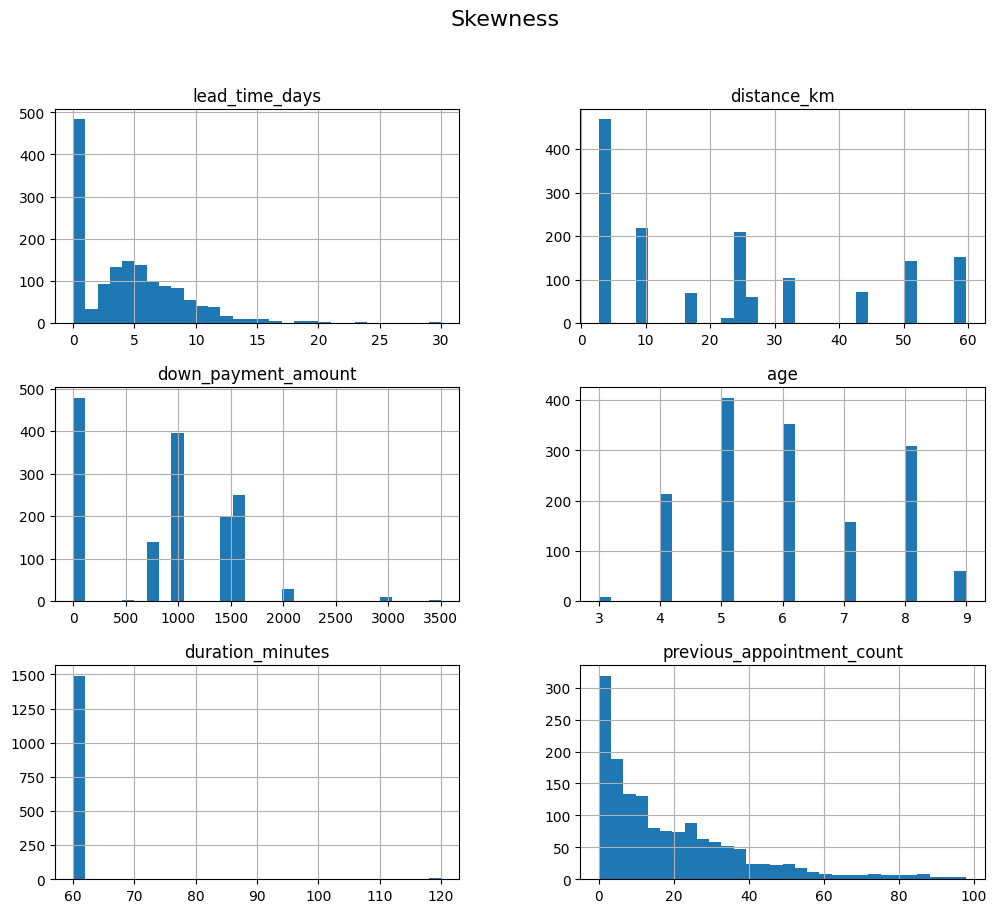

Skewness Report:
 duration_minutes              10.428416
previous_appointment_count     1.522120
lead_time_days                 1.451287
distance_km                    0.641041
age                            0.263947
down_payment_amount            0.094487
dtype: float64


In [ ]:
# Skewness
num_cols = ['lead_time_days', 'distance_km', 'down_payment_amount',
            'age', 'duration_minutes', 'previous_appointment_count']

df_clean[num_cols].hist(figsize=(12, 10), bins=30)
plt.suptitle("Skewness", fontsize=16)
plt.show()

skew_vals = df_clean[num_cols].skew().sort_values(ascending=False)
print("Skewness Report:\n", skew_vals)

In [ ]:
# Check for impossible values of duration_minutes
print(df_clean['duration_minutes'].describe(percentiles=[0.99]))

count    1506.000000
mean       60.537849
std         5.604006
min        60.000000
50%        60.000000
99%        60.000000
max       120.000000
Name: duration_minutes, dtype: float64


In [ ]:
# Apply log1p (log(1+x)) to compress the outliers
vars_to_fix = ['duration_minutes', 'previous_appointment_count', 'lead_time_days', 'distance_km']

for col in vars_to_fix:
    df_clean[f'log_{col}'] = np.log1p(df_clean[col])

print("Created columns:", [f'log_{col}' for col in vars_to_fix])

Created columns: ['log_duration_minutes', 'log_previous_appointment_count', 'log_lead_time_days', 'log_distance_km']


In [ ]:
df_clean.head()

,date,id,appointment_start_time_24h,appointment_end_time_24h,duration_minutes,day_of_the_week,service_type,has_down_payment,down_payment_amount,down_payment_date,payment_status,payment_method,is_holiday,holiday_type,is_typhoon_risk,typhoon_signal_level,is_rainy_season,attendance_status,lead_time_days,reminder_sent,reminder_date,reminder_time_lag,age,gender,diagnosis,distance_km,is_noshow,lead_time_is_missing,is_weekend,appointment_hour,time_of_day,distance_category,age_group,previous_appointment_count,last_appt_noshow,previous_noshow_count,noshow_ratio,log_duration_minutes,log_previous_appointment_count,log_lead_time_days,log_distance_km
894,2025-07-13,1,15:00,16:00,60,Sun,OT,Yes,3500,07/04/2025,Updated,Gcash,No,Ordinary Day,No,0,Yes,No,9.0,Yes,07/10/2025,3,7,M,SLD,24.133385,0,0,1,15,Afternoon,Moderate,7-9 years,0,0,0,0.0,4.110874,0.000000,2.302585,3.224197
974,2025-07-27,1,12:00,13:00,60,Sun,OT,Yes,1600,7/21/2025,Arrears,BDO,Yes,Special Non-working Holiday,Yes,2,Yes,No,6.0,Yes,7/23/2025,4,7,M,SLD,24.133385,0,0,1,12,Lunch,Moderate,7-9 years,1,0,0,0.0,4.110874,0.693147,1.945910,3.224197
1159,2025-08-24,1,14:00,15:00,60,Sun,OT,Yes,1600,08/09/2025,Updated,Gcash,No,Ordinary Day,No,0,Yes,No,15.0,Yes,8/21/2025,3,7,M,SLD,24.133385,0,0,1,14,Afternoon,Moderate,7-9 years,2,0,0,0.0,4.110874,1.098612,2.772589,3.224197
1283,2025-09-07,1,10:00,11:00,60,Sun,OT,No,0,NaN,Arrears,None,No,Ordinary Day,No,0,Yes,No,0.0,Yes,09/05/2025,2,7,M,SLD,24.133385,0,1,1,10,Morning,Moderate,7-9 years,3,0,0,0.0,4.110874,1.386294,0.000000,3.224197
1358,2025-09-21,1,14:00,15:00,60,Sun,OT,Yes,1000,9/15/2025,Arrears,Gcash,No,Ordinary Day,No,0,Yes,No,6.0,Yes,9/19/2025,2,7,M,SLD,24.133385,0,0,1,14,Afternoon,Moderate,7-9 years,4,0,0,0.0,4.110874,1.609438,1.945910,3.224197


## Exploratory Data Visualization

Exploratory analysis is structured around five hypotheses about no-show behavior. Each visualization set tests a specific hypothesis and reveals patterns that inform both statistical testing and model development.

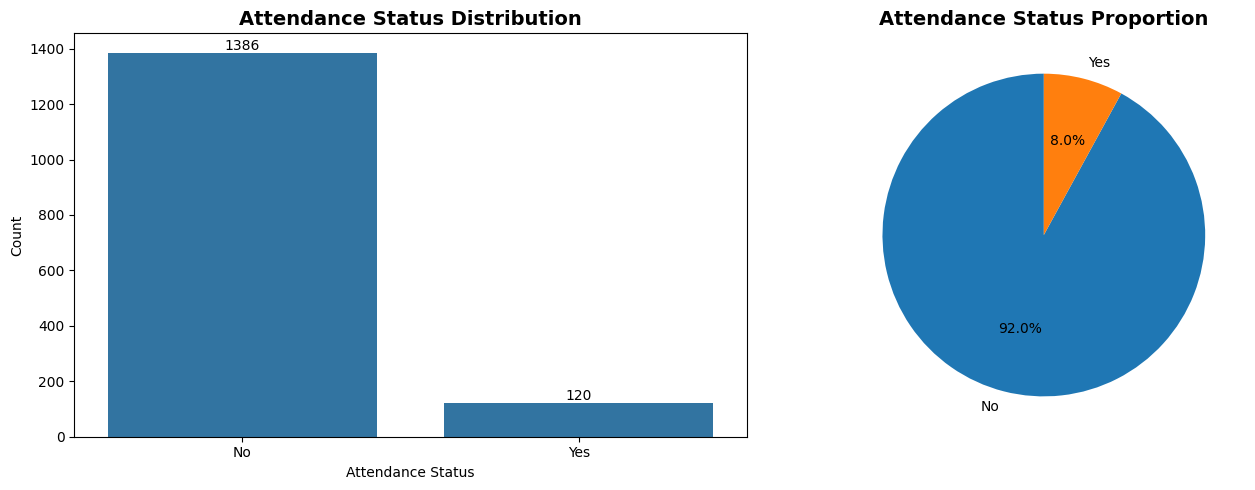

In [ ]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_clean, x='attendance_status', ax=axes[0])
axes[0].set_title('Attendance Status Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Attendance Status')
axes[0].set_ylabel('Count')
for container in axes[0].containers:
    axes[0].bar_label(container)

attendance_counts = df_clean['attendance_status'].value_counts()
axes[1].pie(attendance_counts, labels=attendance_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Attendance Status Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

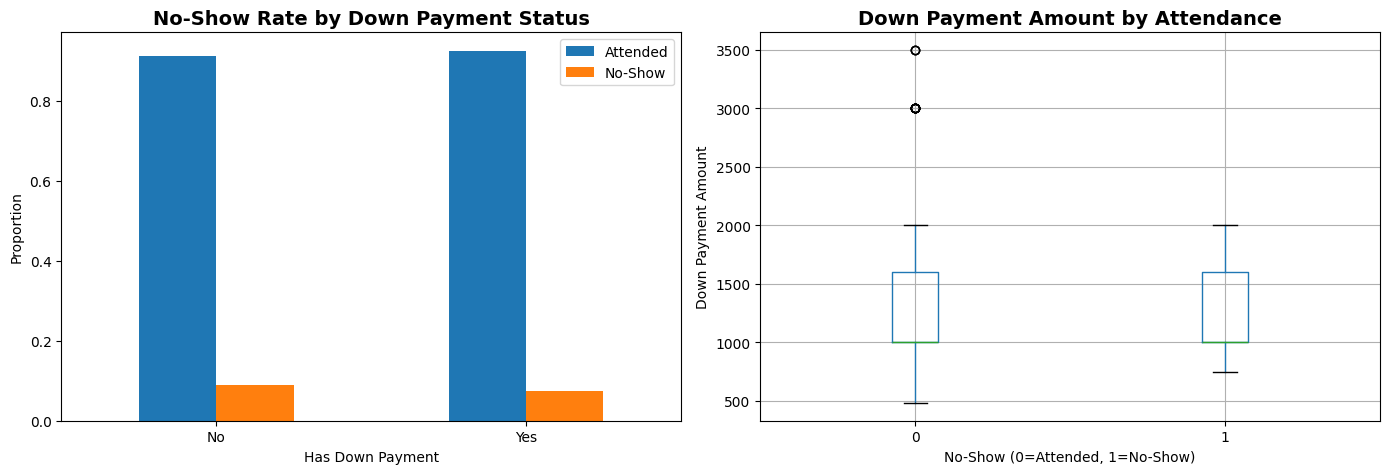

In [ ]:
# H1: Financial Commitment
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pd.crosstab(df_clean['has_down_payment'], df_clean['is_noshow'],
           normalize='index').plot(kind='bar', ax=axes[0])
axes[0].set_title('No-Show Rate by Down Payment Status', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Has Down Payment')
axes[0].set_ylabel('Proportion')
axes[0].legend(['Attended', 'No-Show'])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

df_clean[df_clean['down_payment_amount'] > 0].boxplot(
    column='down_payment_amount', by='is_noshow', ax=axes[1]
)
axes[1].set_title('Down Payment Amount by Attendance', fontsize=14, fontweight='bold')
axes[1].set_xlabel('No-Show (0=Attended, 1=No-Show)')
axes[1].set_ylabel('Down Payment Amount')
plt.suptitle('')

plt.tight_layout()
plt.show()

H1: Financial Commitment Visualization

* There is almost no difference in no-show rates between those who paid a deposit and those who didn't; the proportion of no-shows remains around 8-10% for both groups.
* The median down payment amount for both attendees and no-shows is identical (approx. 1,000), suggesting that the current deposit level isn't high enough to incentivize attendance.
* Even though an IE therapy session costs 3,000, the data shows that paying this full amount upfront is rare. Most people stick to the standard deposit (median 1,000). Every single parent who paid the full for the IE session attended their appointment. There were zero no-shows at that price point.
* For everyone else (those paying a standard deposit or no deposit), the no-show rate remains stubbornly similar.

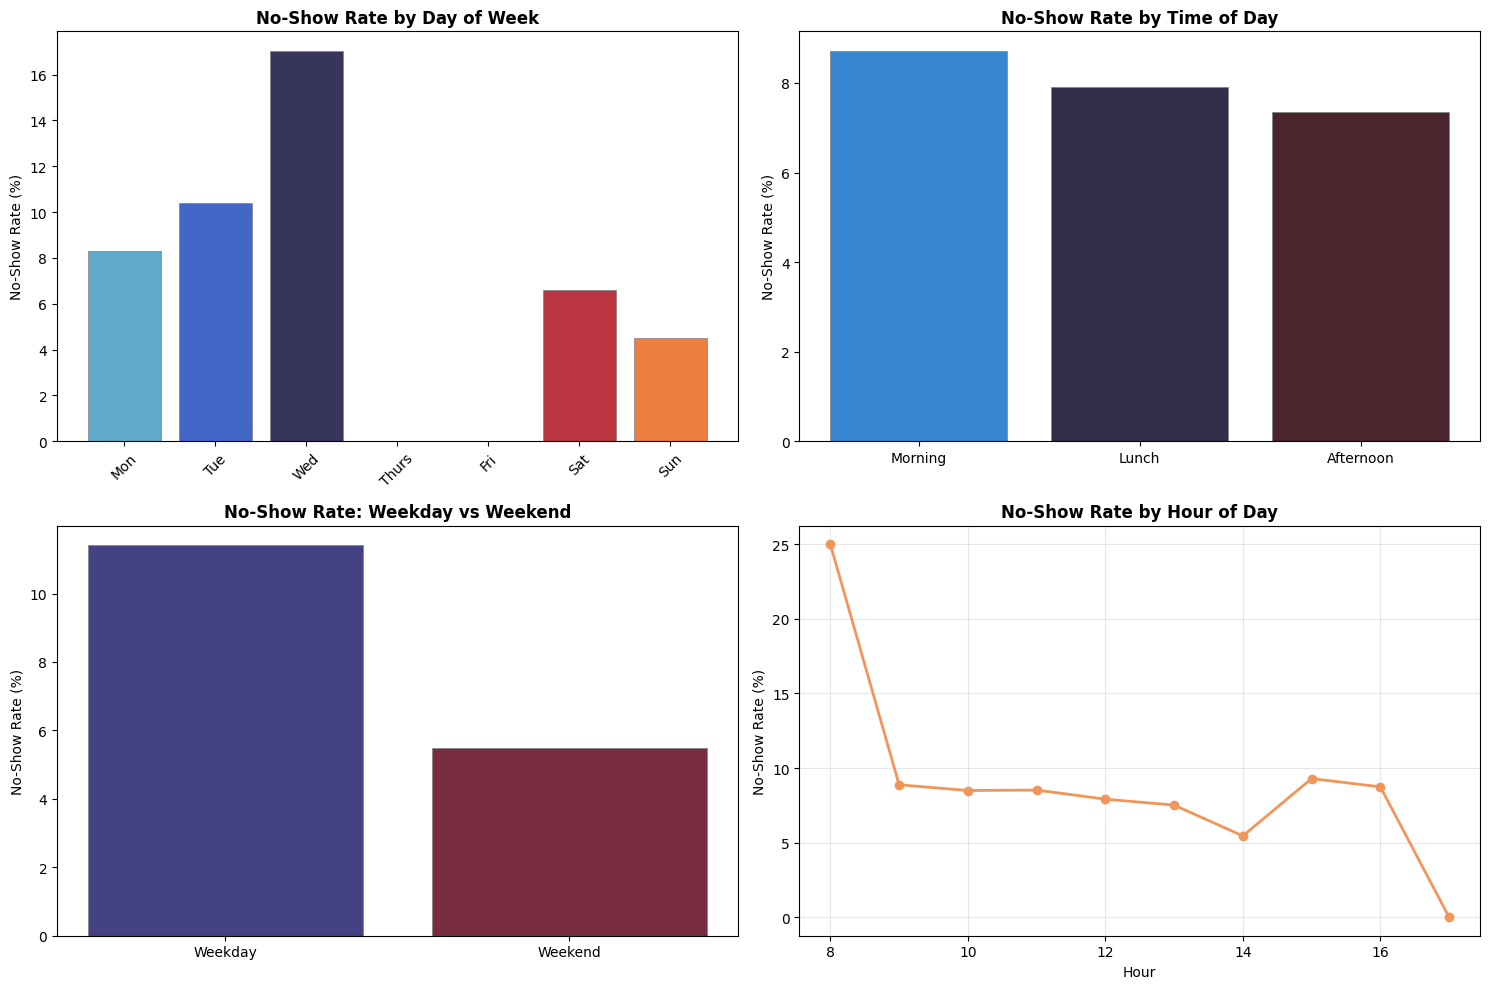

In [ ]:
# H2: Temporal Patterns
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
day_colors = sns.color_palette("icefire", n_colors=7)
time_colors = sns.color_palette("icefire", n_colors=4)
weekend_colors = sns.color_palette("icefire", n_colors=2)
line_color = sns.color_palette("icefire", n_colors=10)[-1]

# By day of week
day_order = ['Mon', 'Tue', 'Wed', 'Thurs', 'Fri', 'Sat', 'Sun']
day_noshow = df_clean.groupby('day_of_the_week')['is_noshow'].mean().reindex(day_order) * 100

axes[0, 0].bar(day_noshow.index, day_noshow.values,
               color=day_colors, edgecolor='gray', linewidth=0.5)
axes[0, 0].set_title('No-Show Rate by Day of Week', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('No-Show Rate (%)')
axes[0, 0].tick_params(axis='x', rotation=45)

# By time of day
time_order = ['Morning', 'Lunch', 'Afternoon']
time_noshow = df_clean.groupby('time_of_day')['is_noshow'].mean() * 100
time_noshow = time_noshow.reindex([t for t in time_order if t in time_noshow.index])

axes[0, 1].bar(time_noshow.index, time_noshow.values,
               color=time_colors, edgecolor='gray', linewidth=0.5)
axes[0, 1].set_title('No-Show Rate by Time of Day', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('No-Show Rate (%)')

# Weekend vs Weekday
weekend_noshow = df_clean.groupby('is_weekend')['is_noshow'].mean() * 100
axes[1, 0].bar(['Weekday', 'Weekend'], weekend_noshow.values,
               color=weekend_colors, edgecolor='gray', linewidth=0.5)
axes[1, 0].set_title('No-Show Rate: Weekday vs Weekend', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('No-Show Rate (%)')

# By hour
hour_noshow = df_clean.groupby('appointment_hour')['is_noshow'].mean() * 100
axes[1, 1].plot(hour_noshow.index, hour_noshow.values,
                marker='o', color=line_color, linewidth=2)
axes[1, 1].set_title('No-Show Rate by Hour of Day', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Hour')
axes[1, 1].set_ylabel('No-Show Rate (%)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

H2: Temportal Patterns Visualization

* Although Sunday (467) and Saturday (408) have by far the highest patient volume, they have the lowest no-show rates (4-6%). Wednesday has less than half the volume of Sunday (182 vs 467) but the highest no-show rate (17%). This indicates a specific mid-week scheduling friction for patients.

* People are twice as likely to miss a weekday appointment than a weekend one.

* The no-show rate declines throughout the day, hitting 0% by 5:00 PM.

* Early morning is the most volatile time, with a 25% no-show rate, nearly triple the daily average.



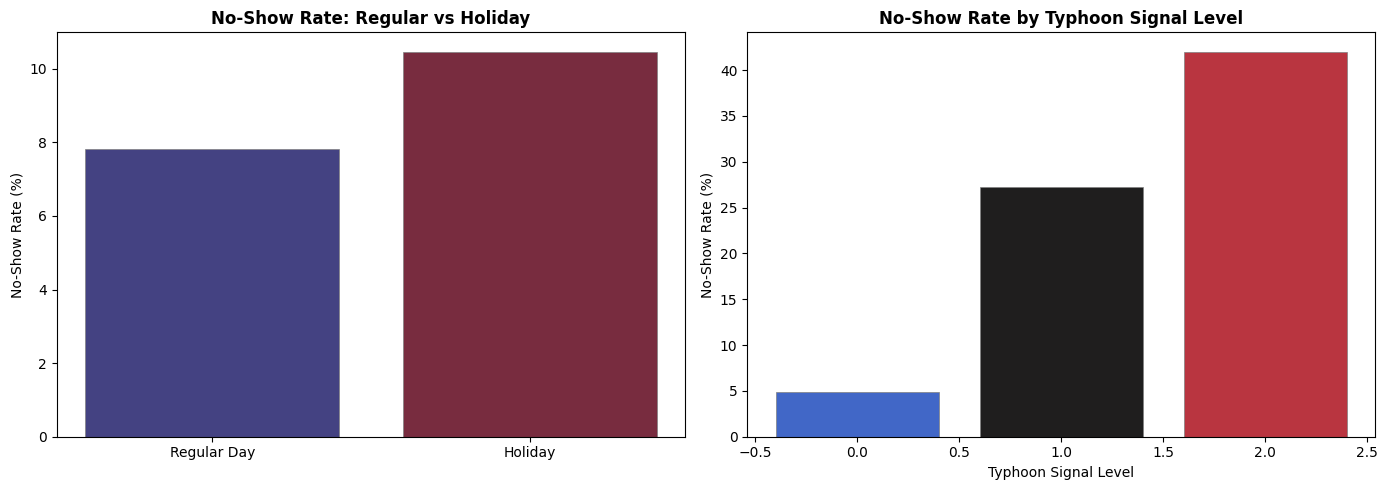

In [ ]:
# H3: Environmental Factors
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

holiday_colors = sns.color_palette("icefire", n_colors=2)

holiday_noshow = df_clean.groupby('is_holiday')['is_noshow'].mean() * 100
axes[0].bar(['Regular Day', 'Holiday'], holiday_noshow.values,
            color=holiday_colors, edgecolor='gray', linewidth=0.5)
axes[0].set_title('No-Show Rate: Regular vs Holiday', fontsize=12, fontweight='bold')
axes[0].set_ylabel('No-Show Rate (%)')


typhoon_noshow = df_clean.groupby('typhoon_signal_level')['is_noshow'].mean() * 100
typhoon_colors = sns.color_palette("icefire", n_colors=len(typhoon_noshow))

axes[1].bar(typhoon_noshow.index, typhoon_noshow.values,
            color=typhoon_colors, edgecolor='gray', linewidth=0.5)
axes[1].set_title('No-Show Rate by Typhoon Signal Level', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Typhoon Signal Level')
axes[1].set_ylabel('No-Show Rate (%)')

plt.tight_layout()
plt.show()

H3: Environmental Factor Visualization

* Public holidays show elevated no-show rates compared to regular days.
* Higher typhoon signal levels correlate strongly with increased no-show rates.

/tmp/ipython-input-2049296547.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_noshow = df_clean.groupby('age_group')['is_noshow'].mean() * 100
/tmp/ipython-input-2049296547.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dist_noshow = df_clean.groupby('distance_category')['is_noshow'].mean() * 100


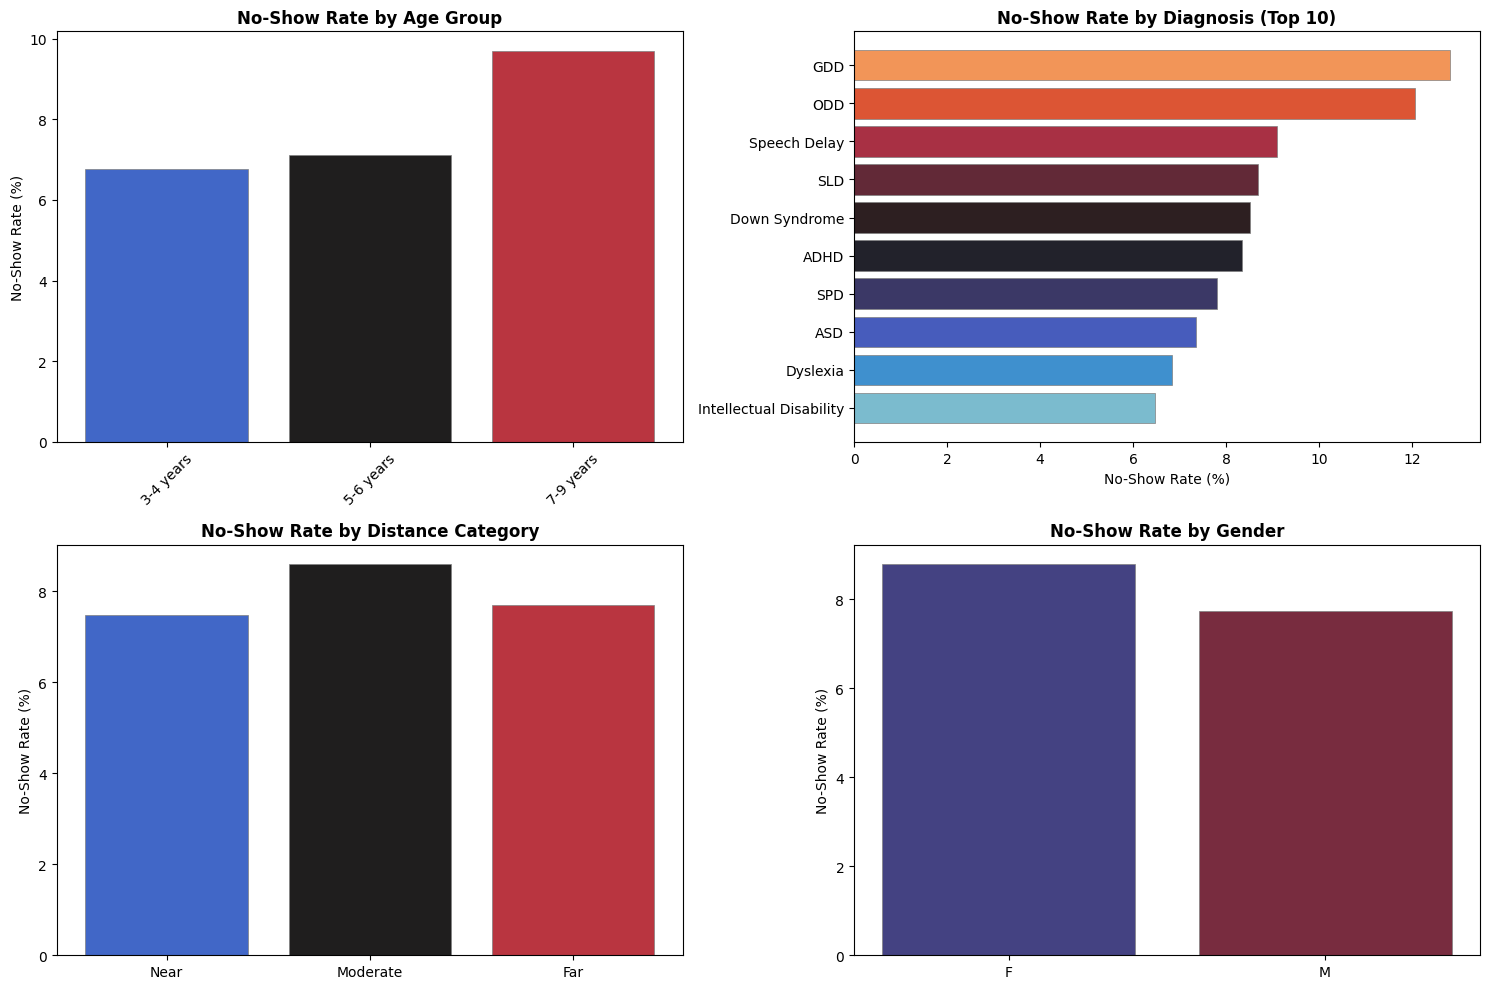

In [ ]:
# H4: Demographics and Clinical Profiles
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Age groups
age_noshow = df_clean.groupby('age_group')['is_noshow'].mean() * 100
age_colors = sns.color_palette("icefire", n_colors=len(age_noshow))

axes[0, 0].bar(range(len(age_noshow)), age_noshow.values,
               color=age_colors, edgecolor='gray', linewidth=0.5)
axes[0, 0].set_xticks(range(len(age_noshow)))
axes[0, 0].set_xticklabels(age_noshow.index, rotation=45)
axes[0, 0].set_title('No-Show Rate by Age Group', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('No-Show Rate (%)')

# Diagnosis (top 10)
diagnosis_noshow = df_clean.groupby('diagnosis')['is_noshow'].mean().sort_values(ascending=False) * 100
top_diagnoses = diagnosis_noshow.head(10)

diag_colors = sns.color_palette("icefire", n_colors=len(top_diagnoses))[::-1]

axes[0, 1].barh(range(len(top_diagnoses)), top_diagnoses.values,
                color=diag_colors, edgecolor='gray', linewidth=0.5)
axes[0, 1].set_yticks(range(len(top_diagnoses)))
axes[0, 1].set_yticklabels(top_diagnoses.index)
axes[0, 1].set_title('No-Show Rate by Diagnosis (Top 10)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('No-Show Rate (%)')
axes[0, 1].invert_yaxis()

# Distance categories
dist_noshow = df_clean.groupby('distance_category')['is_noshow'].mean() * 100
dist_colors = sns.color_palette("icefire", n_colors=len(dist_noshow))

axes[1, 0].bar(range(len(dist_noshow)), dist_noshow.values,
               color=dist_colors, edgecolor='gray', linewidth=0.5)
axes[1, 0].set_xticks(range(len(dist_noshow)))
axes[1, 0].set_xticklabels(dist_noshow.index)
axes[1, 0].set_title('No-Show Rate by Distance Category', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('No-Show Rate (%)')

# Gender
gender_noshow = df_clean.groupby('gender')['is_noshow'].mean() * 100
gender_colors = sns.color_palette("icefire", n_colors=len(gender_noshow))

axes[1, 1].bar(gender_noshow.index, gender_noshow.values,
               color=gender_colors, edgecolor='gray', linewidth=0.5)
axes[1, 1].set_title('No-Show Rate by Gender', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('No-Show Rate (%)')

plt.tight_layout()
plt.show()

H4: Demographics and Clinical Profiles Visualization

* Families with a Global Developmental Delay (GDD) or Oppositional Defiant Disorder (ODD) diagnosis have the highest no-show rates, peaking between 12-13%.
* Older children (7-9 years) are significantly more likely to miss appointments (nearly 10%) compared to the 3-4 year old group (~7%).
* Counter-intuitively, those living a "Moderate" distance away have a higher no-show rate (~ 8.5%) than those living "Far" (~7.5%). This suggests that those traveling long distances plan more rigorously, while those at moderate distances may be more susceptible to traffic or "last minute" cancellations.

/tmp/ipython-input-869139233.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ratio_noshow = df_clean.groupby(ratio_bins)['is_noshow'].mean() * 100


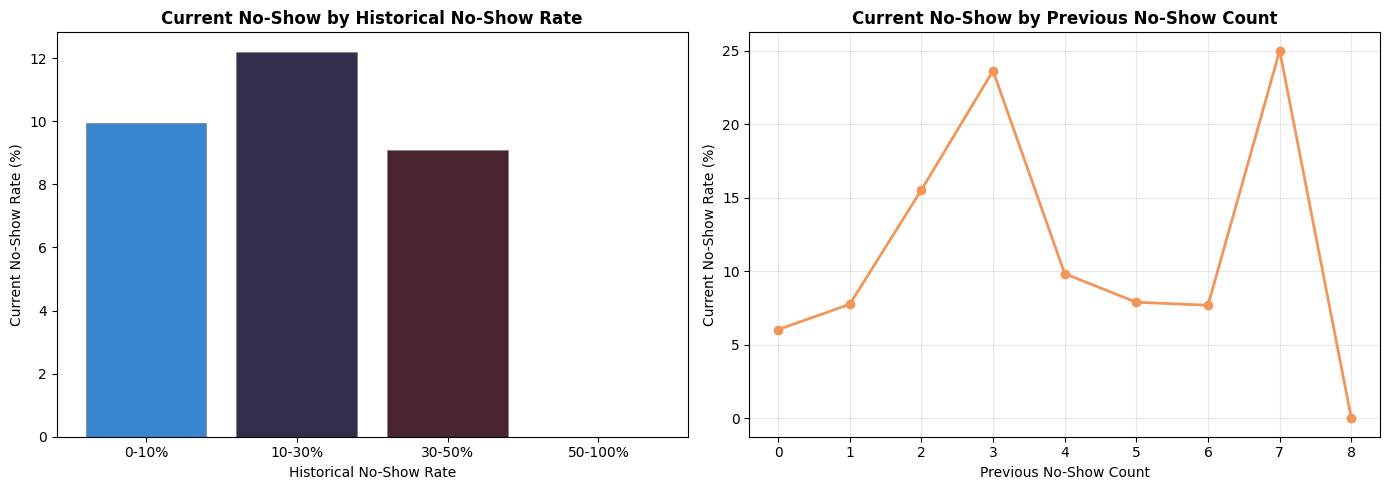

In [ ]:
# H5: Historical Behavior
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ratio_bins = pd.cut(df_clean['noshow_ratio'], bins=[0, 0.1, 0.3, 0.5, 1.0],
                   labels=['0-10%', '10-30%', '30-50%', '50-100%'])
ratio_noshow = df_clean.groupby(ratio_bins)['is_noshow'].mean() * 100

ratio_colors = sns.color_palette("icefire", n_colors=len(ratio_noshow))

axes[0].bar(range(len(ratio_noshow)), ratio_noshow.values,
            color=ratio_colors, edgecolor='gray', linewidth=0.5)
axes[0].set_xticks(range(len(ratio_noshow)))
axes[0].set_xticklabels(ratio_noshow.index)
axes[0].set_title('Current No-Show by Historical No-Show Rate', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Historical No-Show Rate')
axes[0].set_ylabel('Current No-Show Rate (%)')


prev_noshow_grouped = df_clean.groupby('previous_noshow_count')['is_noshow'].mean() * 100

line_color = sns.color_palette("icefire", n_colors=10)[-1]

axes[1].plot(prev_noshow_grouped.index[:10], prev_noshow_grouped.values[:10],
             marker='o', color=line_color, linewidth=2)
axes[1].set_title('Current No-Show by Previous No-Show Count', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Previous No-Show Count')
axes[1].set_ylabel('Current No-Show Rate (%)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

H5: Historical Behavior Visualization
* Patients with a past no-show rate between 10-30% are highest risk group, currently missing appointments at a rate of 12%.
* There is a volatile spike where patients who have missed 7 previous appointments have a 25% current no-show rate. However, once a patient hits 8 misses, the rate drops to 0%.

## Correlation Analysis

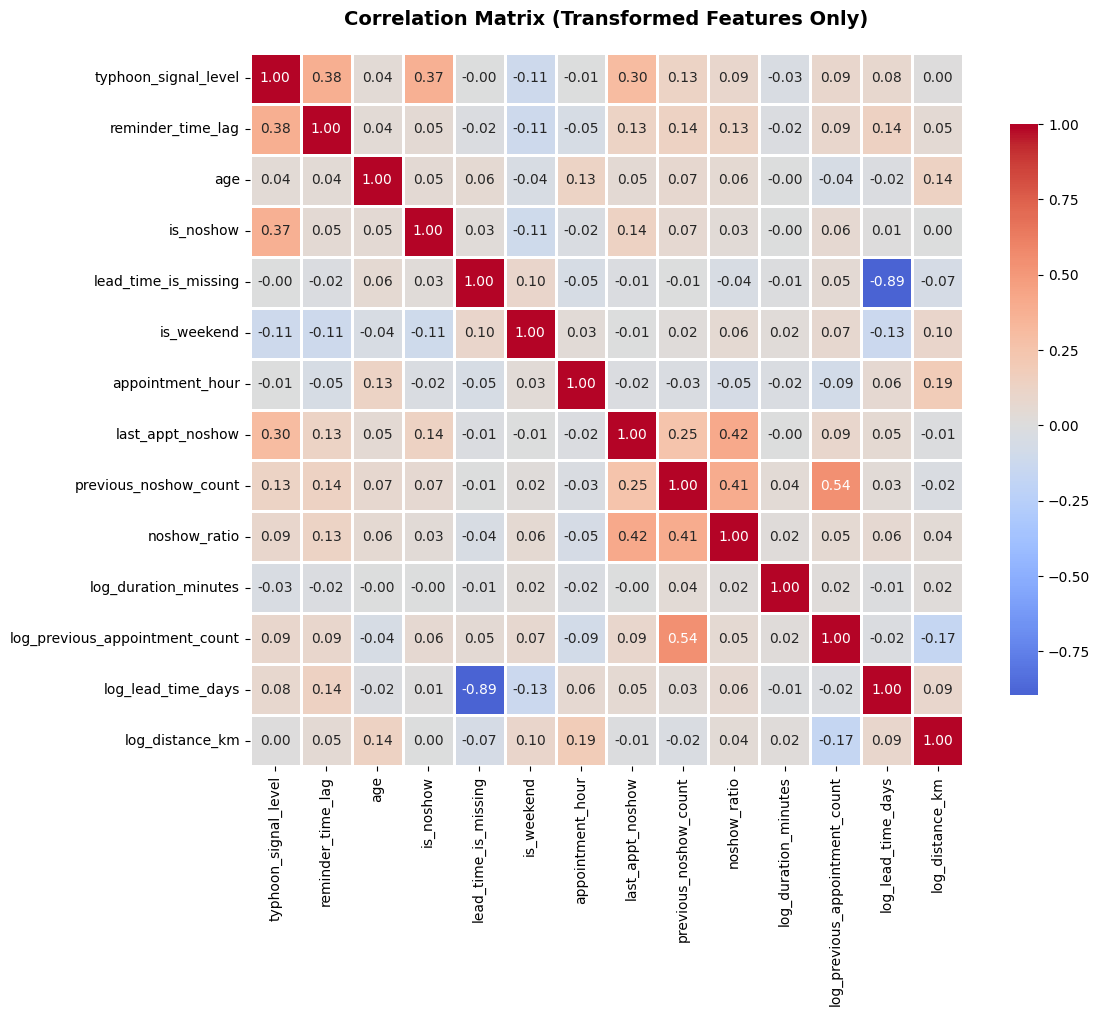

In [ ]:
# Correlation heatmap for numerical variables
numerical_cols = df_clean.select_dtypes(include=[np.number]).columns

drop_cols = ['id', 'lead_time_days', 'distance_km', 'down_payment_amount',
             'previous_appointment_count', 'duration_minutes']

corr_cols = [col for col in numerical_cols if col not in drop_cols]

plt.figure(figsize=(12, 10))
corr_matrix = df_clean[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
           square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix (Transformed Features Only)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [ ]:
# Correlations with target variable
target_corr = df_clean[numerical_cols].corr()['is_noshow'].sort_values(ascending=False)

print("Top 15 Correlations with No-Show:")
print(target_corr.head(15))
print("\nBottom 10 Correlations with No-Show:")
print(target_corr.tail(10))

Top 15 Correlations with No-Show:
is_noshow                         1.000000
typhoon_signal_level              0.374771
last_appt_noshow                  0.140893
previous_noshow_count             0.067219
log_previous_appointment_count    0.064145
previous_appointment_count        0.062979
reminder_time_lag                 0.048758
age                               0.047235
lead_time_days                    0.035661
noshow_ratio                      0.034068
lead_time_is_missing              0.025444
id                                0.020166
log_lead_time_days                0.008049
log_distance_km                   0.000292
duration_minutes                 -0.001988
Name: is_noshow, dtype: float64

Bottom 10 Correlations with No-Show:
lead_time_is_missing    0.025444
id                      0.020166
log_lead_time_days      0.008049
log_distance_km         0.000292
duration_minutes       -0.001988
log_duration_minutes   -0.002156
distance_km            -0.007864
appointment_hour    

In [ ]:
# Chi-square tests for categorical variables
categorical_cols = ['has_down_payment', 'day_of_the_week', 'is_holiday',
                   'is_weekend', 'service_type', 'payment_status',
                   'diagnosis', 'gender', 'time_of_day']

chi_square_results = []
for col in categorical_cols:
    if col in df_clean.columns:
        contingency_table = pd.crosstab(df_clean[col], df_clean['is_noshow'])
        chi2, p_value, dof, expected = chi2_contingency(contingency_table)
        chi_square_results.append({
            'Variable': col,
            'Chi-Square': chi2,
            'p-value': p_value,
            'Significant': 'Yes' if p_value < 0.05 else 'No'
        })

chi_df = pd.DataFrame(chi_square_results).sort_values('p-value')
print("\nChi-Square Tests for Categorical Variables:")
chi_df


Chi-Square Tests for Categorical Variables:


,Variable,Chi-Square,p-value,Significant
1,day_of_the_week,31.859274,0.000006,Yes
3,is_weekend,16.750564,0.000043,Yes
5,payment_status,13.292402,0.000266,Yes
4,service_type,0.811994,0.367531,No
0,has_down_payment,0.610368,0.434649,No
2,is_holiday,0.456402,0.499310,No
7,gender,0.257334,0.611958,No
8,time_of_day,0.840494,0.656885,No
6,diagnosis,7.463700,0.760386,No


## Hypothesis Testing

### H1: Financial Commitment

In [ ]:
print("="*80)
print("H1: FINANCIAL COMMITMENT")
print("="*80)
print("H0: There is no significant difference in cancellation rates between patients who pay a down payment or in advance and those who do not.")
print("H1: Patients who pay a down payment or in advance have significantly lower cancellation rates than those who do not.\n")

with_payment = df_clean[df_clean['has_down_payment'] == 'Yes']['is_noshow']
without_payment = df_clean[df_clean['has_down_payment'] == 'No']['is_noshow']

rate_with = with_payment.mean() * 100
rate_without = without_payment.mean() * 100

print(f"No-show rate WITH down payment: {rate_with:.2f}%")
print(f"No-show rate WITHOUT down payment: {rate_without:.2f}%")
print(f"Difference: {abs(rate_with - rate_without):.2f}")

# Chi-square test
contingency = pd.crosstab(df_clean['has_down_payment'], df_clean['is_noshow'])
chi2, p_value, dof, expected = chi2_contingency(contingency)

print(f"\nChi-Square Test:")
print(f"  Chi-square: {chi2:.4f}")
print(f"  p-value: {p_value:.4f}")

# T-test
t_stat, t_pvalue = ttest_ind(without_payment, with_payment)
print(f"\nT-Test:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {t_pvalue:.4f}")

conclusion = "REJECT H0" if p_value < 0.05 else "FAIL TO REJECT H0"
print(f"\nConclusion (α=0.05): {conclusion}")

H1: FINANCIAL COMMITMENT
H0: There is no significant difference in cancellation rates between patients who pay a down payment or in advance and those who do not.
H1: Patients who pay a down payment or in advance have significantly lower cancellation rates than those who do not.

No-show rate WITH down payment: 7.55%
No-show rate WITHOUT down payment: 8.88%
Difference: 1.33

Chi-Square Test:
  Chi-square: 0.6104
  p-value: 0.4346

T-Test:
  t-statistic: 0.8834
  p-value: 0.3772

Conclusion (α=0.05): FAIL TO REJECT H0


### H2: Temporal Patterns

In [ ]:
print("="*80)
print("H2: TEMPORAL PATTERNS")
print("="*80)
print("H0: Cancellation rates do not differ by day of the week or appointment time.")
print("H1: Cancellation rates differ significantly by day of the week and/or appointment time.\n")

# Day of week ANOVA
day_groups = [df_clean[df_clean['day_of_the_week'] == day]['is_noshow'].values
             for day in df_clean['day_of_the_week'].unique()]
f_stat_day, p_value_day = f_oneway(*day_groups)

print("Day of Week Rates:")
day_rates = df_clean.groupby('day_of_the_week')['is_noshow'].mean() * 100
for day, rate in day_rates.items():
    print(f"  {day}: {rate:.2f}%")

print(f"\nANOVA (Day of Week):")
print(f"  F-statistic: {f_stat_day:.4f}")
print(f"  p-value: {p_value_day:.4f}")

# Weekend vs Weekday
weekday = df_clean[df_clean['is_weekend'] == 0]['is_noshow']
weekend = df_clean[df_clean['is_weekend'] == 1]['is_noshow']
t_stat_weekend, p_value_weekend = ttest_ind(weekend, weekday)

print(f"\nWeekday: {weekday.mean()*100:.2f}%")
print(f"Weekend: {weekend.mean()*100:.2f}%")
print(f"T-test p-value: {p_value_weekend:.4f}")

conclusion = "REJECT H0" if min(p_value_day, p_value_weekend) < 0.05 else "FAIL TO REJECT H0"
print(f"\nConclusion (α=0.05): {conclusion}")

H2: TEMPORAL PATTERNS
H0: Cancellation rates do not differ by day of the week or appointment time.
H1: Cancellation rates differ significantly by day of the week and/or appointment time.

Day of Week Rates:
  Fri: 0.00%
  Mon: 8.29%
  Sat: 6.62%
  Sun: 4.50%
  Tue: 10.41%
  Wed: 17.03%

ANOVA (Day of Week):
  F-statistic: 6.4836
  p-value: 0.0000

Weekday: 11.41%
Weekend: 5.49%
T-test p-value: 0.0000

Conclusion (α=0.05): REJECT H0


### H3: Environmental Factors

In [ ]:
print("="*80)
print("H3: ENVIRONMENTAL FACTORS")
print("="*80)
print("H0: Government-declared holidays and local typhoon signals have no effect on patient attendance.")
print("H1: Patient cancellations are significantly higher on government-declared holidays and during local typhoon signals compared to normal days.")

# Holiday effect
regular = df_clean[df_clean['is_holiday'] == 'No']['is_noshow']
holiday = df_clean[df_clean['is_holiday'] == 'Yes']['is_noshow']

print(f"Regular days: {regular.mean()*100:.2f}%")
print(f"Holidays: {holiday.mean()*100:.2f}%")

t_stat_holiday, p_value_holiday = ttest_ind(holiday, regular)
print(f"\nT-test (Holiday):")
print(f"  t-statistic: {t_stat_holiday:.4f}")
print(f"  p-value: {p_value_holiday:.4f}")

# Typhoon effect
no_typhoon = df_clean[df_clean['typhoon_signal_level'] == 0]['is_noshow']
with_typhoon = df_clean[df_clean['typhoon_signal_level'] > 0]['is_noshow']

print(f"\nNo typhoon: {no_typhoon.mean()*100:.2f}%")
print(f"With typhoon: {with_typhoon.mean()*100:.2f}%")

t_stat_typhoon, p_value_typhoon = ttest_ind(with_typhoon, no_typhoon)
print(f"\nT-test (Typhoon):")
print(f"  t-statistic: {t_stat_typhoon:.4f}")
print(f"  p-value: {p_value_typhoon:.4f}")

conclusion = "REJECT H0" if min(p_value_holiday, p_value_typhoon) < 0.05 else "FAIL TO REJECT H0"
print(f"\nConclusion (α=0.05): {conclusion}")

H3: ENVIRONMENTAL FACTORS
H0: Government-declared holidays and local typhoon signals have no effect on patient attendance.
H1: Patient cancellations are significantly higher on government-declared holidays and during local typhoon signals compared to normal days.
Regular days: 7.82%
Holidays: 10.47%

T-test (Holiday):
  t-statistic: 0.8803
  p-value: 0.3789

No typhoon: 4.87%
With typhoon: 40.77%

T-test (Typhoon):
  t-statistic: 15.5571
  p-value: 0.0000

Conclusion (α=0.05): REJECT H0


### H4: Demographic and Clinical Profiles

In [ ]:
print("="*80)
print("H4: DEMOGRAPHIC AND CLINICAL PROFILES")
print("="*80)
print("H0: Cancellation rates do not vary across age groups, diagnosis categories, or residential distances.")
print("H1: Cancellation rates differ significantly among age groups, diagnosis categories, and residential distance categories (Near / Moderate / Far)\n")

# Age groups
age_groups = [df_clean[df_clean['age_group'] == grp]['is_noshow'].values
             for grp in df_clean['age_group'].dropna().unique()]
f_stat_age, p_value_age = f_oneway(*age_groups)

print("Age Groups:")
age_rates = df_clean.groupby('age_group')['is_noshow'].mean() * 100
for grp, rate in age_rates.items():
    print(f"  {grp}: {rate:.2f}%")
print(f"  ANOVA p-value: {p_value_age:.4f}")

# Diagnosis
print("\nTop 5 Diagnoses:")
diagnosis_rates = df_clean.groupby('diagnosis')['is_noshow'].mean().sort_values(ascending=False) * 100
print(diagnosis_rates.head())

top_diagnoses = diagnosis_rates.head(5).index
diagnosis_groups = [df_clean[df_clean['diagnosis'] == diag]['is_noshow'].values
                   for diag in top_diagnoses]
f_stat_diag, p_value_diag = f_oneway(*diagnosis_groups)
print(f"  ANOVA p-value: {p_value_diag:.4f}")

# Distance
dist_groups = [df_clean[df_clean['distance_category'] == cat]['is_noshow'].values
              for cat in df_clean['distance_category'].dropna().unique()]
f_stat_dist, p_value_dist = f_oneway(*dist_groups)

print("\nDistance Categories:")
dist_rates = df_clean.groupby('distance_category')['is_noshow'].mean() * 100
for cat, rate in dist_rates.items():
    print(f"  {cat}: {rate:.2f}%")
print(f"  ANOVA p-value: {p_value_dist:.4f}")

conclusion = "REJECT H0" if min(p_value_age, p_value_diag, p_value_dist) < 0.05 else "FAIL TO REJECT H0"
print(f"\nConclusion (α=0.05): {conclusion}")

H4: DEMOGRAPHIC AND CLINICAL PROFILES
H0: Cancellation rates do not vary across age groups, diagnosis categories, or residential distances.
H1: Cancellation rates differ significantly among age groups, diagnosis categories, and residential distance categories (Near / Moderate / Far)

Age Groups:
  3-4 years: 6.76%
  5-6 years: 7.12%
  7-9 years: 9.70%
  ANOVA p-value: 0.1903

Top 5 Diagnoses:
diagnosis
GDD              12.820513
ODD              12.068966
Speech Delay      9.090909
SLD               8.695652
Down Syndrome     8.510638
Name: is_noshow, dtype: float64
  ANOVA p-value: 0.8095

Distance Categories:
  Near: 7.48%
  Moderate: 8.60%
  Far: 7.69%
  ANOVA p-value: 0.7759

Conclusion (α=0.05): FAIL TO REJECT H0


/tmp/ipython-input-3146747869.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_rates = df_clean.groupby('age_group')['is_noshow'].mean() * 100
/tmp/ipython-input-3146747869.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dist_rates = df_clean.groupby('distance_category')['is_noshow'].mean() * 100


### H5: Historical Behavior

In [ ]:
print("="*80)
print("H5: HISTORICAL BEHAVIOR")
print("="*80)
print("H0: A patient’s previous cancellation behavior has no effect on their likelihood of cancelling future appointments.")
print("H1: Patients who cancelled previous appointments are significantly more likely to cancel subsequent appointments compared to those with consistent attendance.\n")

no_prev_noshow = df_clean[df_clean['previous_noshow_count'] == 0]['is_noshow']
has_prev_noshow = df_clean[df_clean['previous_noshow_count'] > 0]['is_noshow']

print(f"No previous no-shows: {no_prev_noshow.mean()*100:.2f}%")
print(f"Has previous no-shows: {has_prev_noshow.mean()*100:.2f}%")

t_stat_hist, p_value_hist = ttest_ind(has_prev_noshow, no_prev_noshow)
print(f"\nT-test:")
print(f"  t-statistic: {t_stat_hist:.4f}")
print(f"  p-value: {p_value_hist:.4f}")

# Correlation
experienced = df_clean[df_clean['log_previous_appointment_count'] > 0]
corr = experienced['noshow_ratio'].corr(experienced['is_noshow'])
print(f"\nCorrelation (noshow_ratio vs current noshow): {corr:.4f}")

conclusion = "REJECT H0" if p_value_hist < 0.05 else "FAIL TO REJECT H0"
print(f"\nConclusion (α=0.05): {conclusion}")

H5: HISTORICAL BEHAVIOR
H0: A patient’s previous cancellation behavior has no effect on their likelihood of cancelling future appointments.
H1: Patients who cancelled previous appointments are significantly more likely to cancel subsequent appointments compared to those with consistent attendance.

No previous no-shows: 6.04%
Has previous no-shows: 10.44%

T-test:
  t-statistic: 3.1396
  p-value: 0.0017

Correlation (noshow_ratio vs current noshow): 0.0327

Conclusion (α=0.05): REJECT H0


## Regression Modeling

In [ ]:
feature_cols = [
    'log_duration_minutes',
    'log_lead_time_days',
    'log_distance_km',
    'log_previous_appointment_count',
    'down_payment_amount',
    'age',
    'lead_time_is_missing',
    'is_weekend',
    'reminder_time_lag',
    'typhoon_signal_level',
    'previous_noshow_count',
    'noshow_ratio',
    'last_appt_noshow'
]

# Encode categorical variables
df_model = df_clean.copy()
categorical_features = ['day_of_the_week', 'service_type', 'payment_status',
                       'payment_method', 'diagnosis', 'gender', 'time_of_day',
                       'has_down_payment', 'is_holiday']

le_dict = {}
for col in categorical_features:
    if col in df_model.columns:
        le = LabelEncoder()
        df_model[f'{col}_encoded'] = le.fit_transform(df_model[col].astype(str))
        le_dict[col] = le
        feature_cols.append(f'{col}_encoded')

# Prepare X and y
feature_cols = [col for col in feature_cols if col in df_model.columns]
X = df_model[feature_cols].fillna(0)
y = df_model['is_noshow']

print(f"Features: {len(feature_cols)}")
print(f"Samples: {len(X)}")
print(f"Class distribution: {y.value_counts().to_dict()}")

Features: 22
Samples: 1506
Class distribution: {0: 1386, 1: 120}


In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {len(X_train)}")
print(f"Test set: {len(X_test)}")

Training set: 1204
Test set: 302


### Logistic Regression

In [ ]:
# Logistic Regression
print("="*80)
print("LOGISTIC REGRESSION")
print("="*80)

# class_weight='balanced' to handle the 92/8 imbalance
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_pred_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_lr):.4f}")

LOGISTIC REGRESSION
Accuracy: 0.7881
Precision: 0.2297
Recall: 0.7083
F1-Score: 0.3469
ROC-AUC: 0.7774


In [ ]:
# Model Diagnostic

print("\n" + "="*80)
print("LOGISTIC REGRESSION MODEL DIAGNOSTICS")
print("="*80)

# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': lr.coef_[0],
    'abs_coefficient': np.abs(lr.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

print("\nTop 15 Most Important Features:")
print(feature_importance.head(15).to_string())

# Prediction distribution
print("\n" + "="*80)
print("PREDICTION DISTRIBUTION ON TEST SET")
print("="*80)
pred_proba_test = lr.predict_proba(X_test_scaled)[:, 1]
print(f"Min probability:    {pred_proba_test.min():.4f}")
print(f"Max probability:    {pred_proba_test.max():.4f}")
print(f"Mean probability:   {pred_proba_test.mean():.4f}")
print(f"Median probability: {np.median(pred_proba_test):.4f}")
print(f"Std probability:    {pred_proba_test.std():.4f}")

# Class predictions
print("\n" + "="*80)
print("PREDICTION VS ACTUAL")
print("="*80)
print(f"Predicted No-Show:  {y_pred_lr.sum():4d} ({y_pred_lr.sum()/len(y_pred_lr)*100:.1f}%)")
print(f"Predicted Show:     {(y_pred_lr == 0).sum():4d} ({(y_pred_lr == 0).sum()/len(y_pred_lr)*100:.1f}%)")
print(f"Actual No-Show:     {y_test.sum():4d} ({y_test.sum()/len(y_test)*100:.1f}%)")
print(f"Actual Show:        {(y_test == 0).sum():4d} ({(y_test == 0).sum()/len(y_test)*100:.1f}%)")

# Confusion Matrix Details
print("\n" + "="*80)
print("DETAILED CONFUSION MATRIX")
print("="*80)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_lr).ravel()
print(f"\n                    Predicted Show    Predicted No-Show")
print(f"Actual Show              {tn:4d}              {fp:4d}")
print(f"Actual No-Show           {fn:4d}              {tp:4d}")
print(f"\nTrue Positives (correctly identified no-shows): {tp}")
print(f"False Positives (incorrectly flagged as no-show): {fp}")
print(f"True Negatives (correctly identified shows): {tn}")
print(f"False Negatives (missed no-shows): {fn}")



LOGISTIC REGRESSION MODEL DIAGNOSTICS

Top 15 Most Important Features:
                           feature  coefficient  abs_coefficient
9             typhoon_signal_level     0.615843         0.615843
0             log_duration_minutes    -0.395409         0.395409
6             lead_time_is_missing     0.314913         0.314913
5                              age     0.248434         0.248434
20        has_down_payment_encoded     0.230094         0.230094
17               diagnosis_encoded     0.206453         0.206453
19             time_of_day_encoded     0.181097         0.181097
15          payment_status_encoded    -0.181072         0.181072
7                       is_weekend    -0.153960         0.153960
3   log_previous_appointment_count     0.126184         0.126184
10           previous_noshow_count     0.113777         0.113777
4              down_payment_amount    -0.112964         0.112964
21              is_holiday_encoded     0.104333         0.104333
18                

/tmp/ipython-input-3133796083.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='coefficient', y='feature', data=feature_importance, palette=colors)


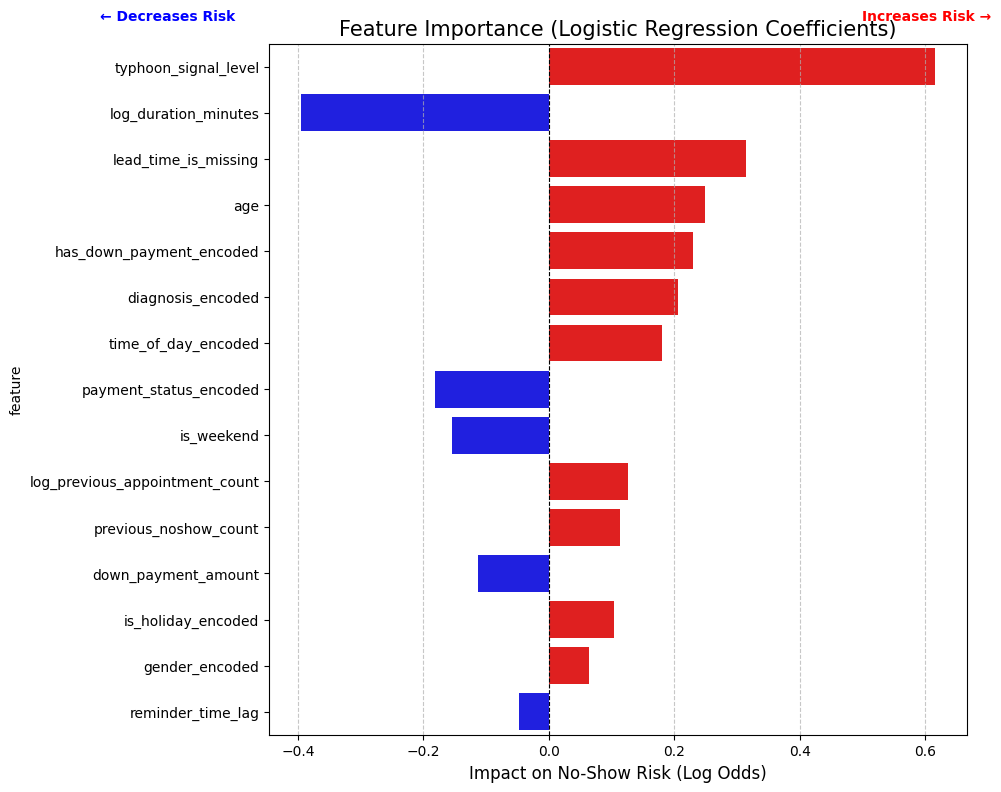

In [ ]:
feature_importance['abs_coefficient'] = feature_importance['coefficient'].abs()
feature_importance = feature_importance.sort_values(by='abs_coefficient', ascending=False).head(15)

plt.figure(figsize=(10, 8))

colors = ['red' if x > 0 else 'blue' for x in feature_importance['coefficient']]

sns.barplot(x='coefficient', y='feature', data=feature_importance, palette=colors)

plt.title('Feature Importance (Logistic Regression Coefficients)', fontsize=15)
plt.xlabel('Impact on No-Show Risk (Log Odds)', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.text(0.5, -1, "Increases Risk →", color='red', fontweight='bold')
plt.text(-0.5, -1, "← Decreases Risk", color='blue', fontweight='bold', ha='right')

plt.tight_layout()
plt.show()

### Random Forest

In [ ]:
# Random Forest
print("="*80)
print("RANDOM FOREST")
print("="*80)

# class_weight='balanced' so the model penalizes missing a No-Show
rf = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42, max_depth=10)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")

RANDOM FOREST
Accuracy: 0.9371
Precision: 1.0000
Recall: 0.2083
F1-Score: 0.3448
ROC-AUC: 0.7633


In [ ]:
# Model Diagnostic

print("\n" + "="*80)
print("RANDOM FOREST MODEL DIAGNOSTICS")
print("="*80)

# Feature importance
rf_feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n" + "="*80)
print("TOP 15 MOST IMPORTANT FEATURES (Random Forest)")
print("="*80)
print(rf_feature_importance.head(15).to_string(index=False))
print(f"\nTotal feature importance sum: {rf_feature_importance['importance'].sum():.4f}")

# Prediction distribution
print("\n" + "="*80)
print("PREDICTION DISTRIBUTION ON TEST SET")
print("="*80)
pred_proba_rf_test = rf.predict_proba(X_test)[:, 1]
print(f"Min probability:    {pred_proba_rf_test.min():.4f}")
print(f"Max probability:    {pred_proba_rf_test.max():.4f}")
print(f"Mean probability:   {pred_proba_rf_test.mean():.4f}")
print(f"Median probability: {np.median(pred_proba_rf_test):.4f}")
print(f"Std probability:    {pred_proba_rf_test.std():.4f}")

# Percentiles
print(f"\n25th percentile:    {np.percentile(pred_proba_rf_test, 25):.4f}")
print(f"75th percentile:    {np.percentile(pred_proba_rf_test, 75):.4f}")
print(f"95th percentile:    {np.percentile(pred_proba_rf_test, 95):.4f}")

# Class predictions
print("\n" + "="*80)
print("PREDICTION VS ACTUAL (Random Forest)")
print("="*80)
print(f"Predicted No-Show:  {y_pred_rf.sum():4d} ({y_pred_rf.sum()/len(y_pred_rf)*100:.1f}%)")
print(f"Predicted Show:     {(y_pred_rf == 0).sum():4d} ({(y_pred_rf == 0).sum()/len(y_pred_rf)*100:.1f}%)")
print(f"Actual No-Show:     {y_test.sum():4d} ({y_test.sum()/len(y_test)*100:.1f}%)的发展)")
print(f"Actual Show:        {(y_test == 0).sum():4d} ({(y_test == 0).sum()/len(y_test)*100:.1f}%)的发展)")

# Confusion Matrix Details
print("\n" + "="*80)
print("DETAILED CONFUSION MATRIX (Random Forest)")
print("="*80)
cm_rf = confusion_matrix(y_test, y_pred_rf)
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()
print(f"\n                    Predicted Show    Predicted No-Show")
print(f"Actual Show              {tn_rf:4d}              {fp_rf:4d}")
print(f"Actual No-Show           {fn_rf:4d}              {tp_rf:4d}")
print(f"\nTrue Positives (correctly identified no-shows): {tp_rf}")
print(f"False Positives (incorrectly flagged as no-show): {fp_rf}")
print(f"True Negatives (correctly identified shows): {tn_rf}")
print(f"False Negatives (missed no-shows): {fn_rf}")

# Additional metrics
print("\n" + "="*80)
print("DETAILED PERFORMANCE METRICS")
print("="*80)
specificity_rf = tn_rf / (tn_rf + fp_rf) if (tn_rf + fp_rf) > 0 else 0
npv_rf = tn_rf / (tn_rf + fn_rf) if (tn_rf + fn_rf) > 0 else 0
print(f"Sensitivity (Recall):     {recall_score(y_test, y_pred_rf):.4f}")
print(f"Specificity:              {specificity_rf:.4f}")
print(f"Precision (PPV):          {precision_score(y_test, y_pred_rf):.4f}")
print(f"Negative Predictive Value: {npv_rf:.4f}")

# Model parameters
print("\n" + "="*80)
print("MODEL PARAMETERS")
print("="*80)
print(f"Number of trees:          {rf.n_estimators}")
print(f"Max depth:                {rf.max_depth}")
print(f"Min samples split:        {rf.min_samples_split}")
print(f"Min samples leaf:         {rf.min_samples_leaf}")
print(f"Number of features used:  {len(feature_cols)}")


RANDOM FOREST MODEL DIAGNOSTICS

TOP 15 MOST IMPORTANT FEATURES (Random Forest)
                       feature  importance
log_previous_appointment_count    0.124432
          typhoon_signal_level    0.120776
                  noshow_ratio    0.077984
             diagnosis_encoded    0.069351
            log_lead_time_days    0.066047
                           age    0.060050
       day_of_the_week_encoded    0.059528
             reminder_time_lag    0.058926
               log_distance_km    0.058901
         previous_noshow_count    0.055177
           down_payment_amount    0.045787
           time_of_day_encoded    0.037082
        payment_method_encoded    0.023126
                    is_weekend    0.022408
          service_type_encoded    0.022161

Total feature importance sum: 1.0000

PREDICTION DISTRIBUTION ON TEST SET
Min probability:    0.0014
Max probability:    0.7278
Mean probability:   0.1586
Median probability: 0.1277
Std probability:    0.1148

25th percentile:    

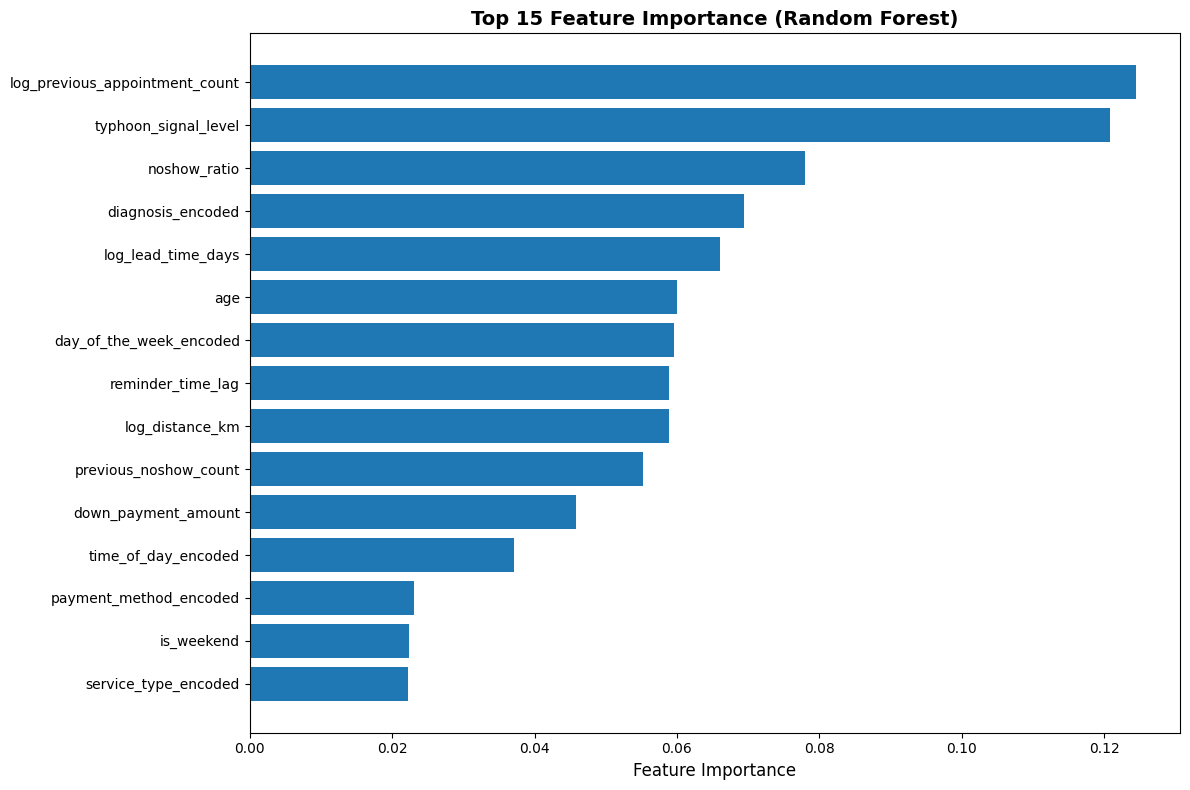

In [ ]:
# Feature Importance Visualization
plt.figure(figsize=(12, 8))
top_features = rf_feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance', fontsize=12)
plt.title('Top 15 Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Gradient Boosting

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight

# Gradient Boosting
print("="*80)
print("GRADIENT BOOSTING (Weighted)")
print("="*80)

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

gb = GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=5)

gb.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_gb = gb.predict(X_test)
y_pred_proba_gb = gb.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_gb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_gb):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_gb):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_gb):.4f}")

GRADIENT BOOSTING (Weighted)
Accuracy: 0.9338
Precision: 0.5909
Recall: 0.5417
F1-Score: 0.5652
ROC-AUC: 0.7214


In [ ]:
# Model Diagnostic

print("\n" + "="*80)
print("GRADIENT BOOSTING MODEL DIAGNOSTIC")
print("="*80)

# Feature importance
gb_feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': gb.feature_importances_
}).sort_values('importance', ascending=False)

print("\n" + "="*80)
print("TOP 15 MOST IMPORTANT FEATURES (Gradient Boosting)")
print("="*80)
print(gb_feature_importance.head(15).to_string(index=False))
print(f"\nTotal feature importance sum: {gb_feature_importance['importance'].sum():.4f}")

# Prediction distribution
print("\n" + "="*80)
print("PREDICTION DISTRIBUTION ON TEST SET")
print("="*80)
pred_proba_gb_test = gb.predict_proba(X_test)[:, 1]
print(f"Min probability:    {pred_proba_gb_test.min():.4f}")
print(f"Max probability:    {pred_proba_gb_test.max():.4f}")
print(f"Mean probability:   {pred_proba_gb_test.mean():.4f}")
print(f"Median probability: {np.median(pred_proba_gb_test):.4f}")
print(f"Std probability:    {pred_proba_gb_test.std():.4f}")

# Percentiles
print(f"\n25th percentile:    {np.percentile(pred_proba_gb_test, 25):.4f}")
print(f"75th percentile:    {np.percentile(pred_proba_gb_test, 75):.4f}")
print(f"95th percentile:    {np.percentile(pred_proba_gb_test, 95):.4f}")

# Class predictions
print("\n" + "="*80)
print("PREDICTION VS ACTUAL (Gradient Boosting)")
print("="*80)
print(f"Predicted No-Show:  {y_pred_gb.sum():4d} ({y_pred_gb.sum()/len(y_pred_gb)*100:.1f}%)的发展)")
print(f"Predicted Show:     {(y_pred_gb == 0).sum():4d} ({(y_pred_gb == 0).sum()/len(y_pred_gb)*100:.1f}%)的发展)")
print(f"Actual No-Show:     {y_test.sum():4d} ({y_test.sum()/len(y_test)*100:.1f}%)的发展)")
print(f"Actual Show:        {(y_test == 0).sum():4d} ({(y_test == 0).sum()/len(y_test)*100:.1f}%)的发展)")

# Confusion Matrix Details
print("\n" + "="*80)
print("DETAILED CONFUSION MATRIX (Gradient Boosting)")
print("="*80)
cm_gb = confusion_matrix(y_test, y_pred_gb)
tn_gb, fp_gb, fn_gb, tp_gb = cm_gb.ravel()
print(f"\n                    Predicted Show    Predicted No-Show")
print(f"Actual Show              {tn_gb:4d}              {fp_gb:4d}")
print(f"Actual No-Show           {fn_gb:4d}              {tp_gb:4d}")
print(f"\nTrue Positives (correctly identified no-shows): {tp_gb}")
print(f"False Positives (incorrectly flagged as no-show): {fp_gb}")
print(f"True Negatives (correctly identified shows): {tn_gb}")
print(f"False Negatives (missed no-shows): {fn_gb}")

# Additional metrics
print("\n" + "="*80)
print("DETAILED PERFORMANCE METRICS")
print("="*80)
specificity_gb = tn_gb / (tn_gb + fp_gb) if (tn_gb + fp_gb) > 0 else 0
pv_gb = tn_gb / (tn_gb + fn_gb) if (tn_gb + fn_gb) > 0 else 0
print(f"Sensitivity (Recall):     {recall_score(y_test, y_pred_gb):.4f}")
print(f"Specificity:              {specificity_gb:.4f}")
print(f"Precision (PPV):          {precision_score(y_test, y_pred_gb):.4f}")
print(f"Negative Predictive Value: {npv_gb:.4f}")

# Model parameters
print("\n" + "="*80)
print("MODEL PARAMETERS")
print("="*80)
print(f"Number of boosting stages: {gb.n_estimators}")
print(f"Learning rate:             {gb.learning_rate}")
print(f"Max depth:                 {gb.max_depth}")
print(f"Min samples split:         {gb.min_samples_split}")
print(f"Min samples leaf:          {gb.min_samples_leaf}")
print(f"Number of features used:   {len(feature_cols)}")


GRADIENT BOOSTING MODEL DIAGNOSTIC

TOP 15 MOST IMPORTANT FEATURES (Gradient Boosting)
                       feature  importance
          typhoon_signal_level    0.220054
log_previous_appointment_count    0.161078
             reminder_time_lag    0.087029
                  noshow_ratio    0.070995
            log_lead_time_days    0.057942
             diagnosis_encoded    0.054640
               log_distance_km    0.052306
                           age    0.049587
            is_holiday_encoded    0.047912
           down_payment_amount    0.046652
       day_of_the_week_encoded    0.042452
           time_of_day_encoded    0.026274
         previous_noshow_count    0.023145
        payment_method_encoded    0.014125
                    is_weekend    0.012767

Total feature importance sum: 1.0000

PREDICTION DISTRIBUTION ON TEST SET
Min probability:    0.0008
Max probability:    0.9896
Mean probability:   0.1603
Median probability: 0.0756
Std probability:    0.2180

25th percenti

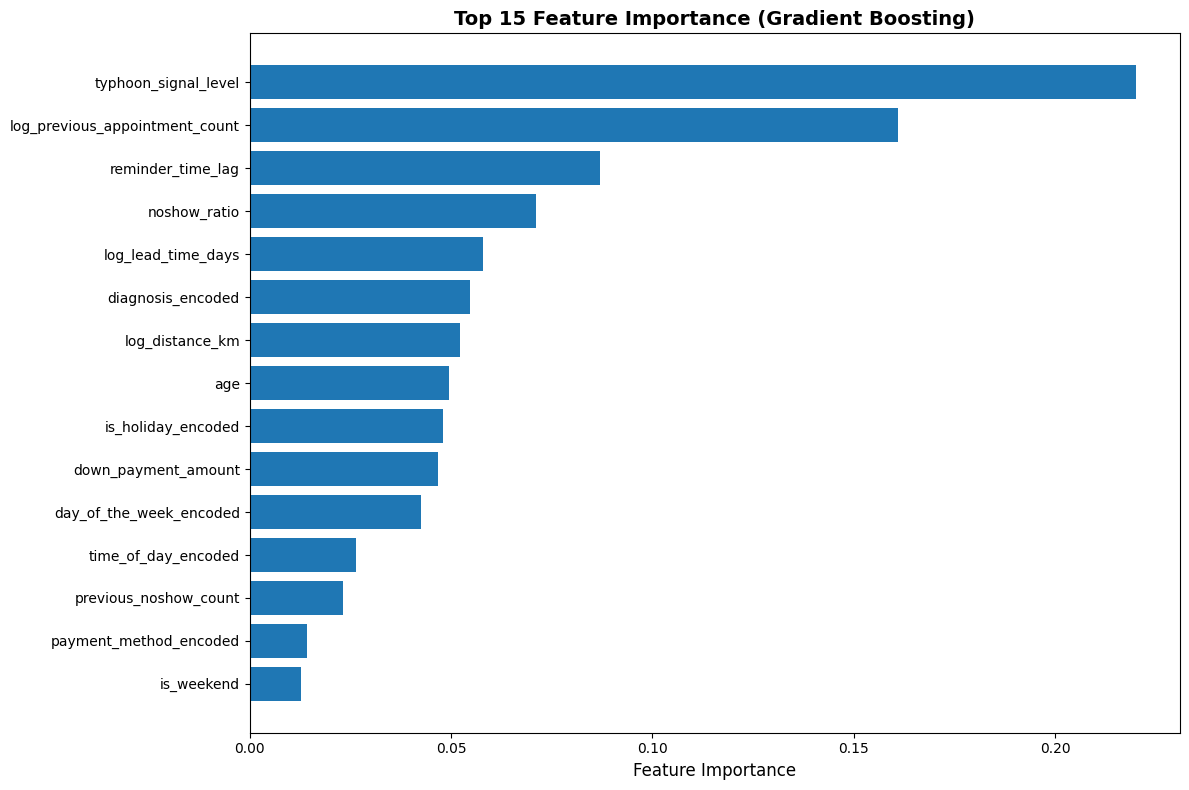

In [ ]:
# Feature Importance Visualization
plt.figure(figsize=(12, 8))
top_features = gb_feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance', fontsize=12)
plt.title('Top 15 Feature Importance (Gradient Boosting)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Model Comparison

In [ ]:
print("\n" + "="*80)
print("MODEL COMPARISON SUMMARY")
print("="*80)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Logistic Regression': [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr),
        roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1])
    ],
    'Random Forest': [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf),
        roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
    ],
    'Gradient Boosting': [
        accuracy_score(y_test, y_pred_gb),
        precision_score(y_test, y_pred_gb),
        recall_score(y_test, y_pred_gb),
        f1_score(y_test, y_pred_gb),
        roc_auc_score(y_test, gb.predict_proba(X_test)[:, 1])
    ]
})

print("\n" + comparison_df.to_string(index=False))

# Identify best model for each metric
print("\n" + "="*80)
print("BEST MODEL BY METRIC")
print("="*80)
for metric in comparison_df['Metric']:
    row = comparison_df[comparison_df['Metric'] == metric].iloc[0]
    best_model = row[1:].idxmax()
    best_value = row[1:].max()
    print(f"{metric:20s}: {best_model:20s} ({best_value:.4f})")

# Feature importance comparison
print("\n" + "="*80)
print("TOP 5 FEATURES BY MODEL")
print("="*80)

# Logistic Regression (using absolute coefficients)
lr_top5 = pd.DataFrame({
    'feature': feature_cols,
    'importance': np.abs(lr.coef_[0])
}).sort_values('importance', ascending=False).head(5)

print("\nLogistic Regression:")
for idx, row in lr_top5.iterrows():
    print(f"  {row['feature']:30s} {row['importance']:.4f}")

print("\nRandom Forest:")
for idx, row in rf_feature_importance.head(5).iterrows():
    print(f"  {row['feature']:30s} {row['importance']:.4f}")

print("\nGradient Boosting:")
for idx, row in gb_feature_importance.head(5).iterrows():
    print(f"  {row['feature']:30s} {row['importance']:.4f}")

# Prediction distribution comparison
print("\n" + "="*80)
print("PREDICTION PROBABILITY DISTRIBUTION")
print("="*80)
pred_proba_lr_test = lr.predict_proba(X_test_scaled)[:, 1]
pred_proba_rf_test = rf.predict_proba(X_test)[:, 1]
pred_proba_gb_test = gb.predict_proba(X_test)[:, 1]

print(f"\n{'Model':<20s} {'Min':>8s} {'Mean':>8s} {'Median':>8s} {'Max':>8s} {'Std':>8s}")
print("-" * 80)
print(f"{'Logistic Regression':<20s} {pred_proba_lr_test.min():8.4f} {pred_proba_lr_test.mean():8.4f} {np.median(pred_proba_lr_test):8.4f} {pred_proba_lr_test.max():8.4f} {pred_proba_lr_test.std():8.4f}")
print(f"{'Random Forest':<20s} {pred_proba_rf_test.min():8.4f} {pred_proba_rf_test.mean():8.4f} {np.median(pred_proba_rf_test):8.4f} {pred_proba_rf_test.max():8.4f} {pred_proba_rf_test.std():8.4f}")
print(f"{'Gradient Boosting':<20s} {pred_proba_gb_test.min():8.4f} {pred_proba_gb_test.mean():8.4f} {np.median(pred_proba_gb_test):8.4f} {pred_proba_gb_test.max():8.4f} {pred_proba_gb_test.std():8.4f}")

print("\n  - Precision & Recall: Critical for identifying no-shows accurately")
print("  - F1-Score: Balance between precision and recall")
print("  - ROC-AUC: Overall discrimination ability")
print("  - Accuracy: Overall correctness (lower weight due to class imbalance)")


MODEL COMPARISON SUMMARY

   Metric  Logistic Regression  Random Forest  Gradient Boosting
 Accuracy             0.788079       0.937086           0.933775
Precision             0.229730       1.000000           0.590909
   Recall             0.708333       0.208333           0.541667
 F1-Score             0.346939       0.344828           0.565217
  ROC-AUC             0.777428       0.763339           0.721373

BEST MODEL BY METRIC
Accuracy            : Random Forest        (0.9371)
Precision           : Random Forest        (1.0000)
Recall              : Logistic Regression  (0.7083)
F1-Score            : Gradient Boosting    (0.5652)
ROC-AUC             : Logistic Regression  (0.7774)

TOP 5 FEATURES BY MODEL

Logistic Regression:
  typhoon_signal_level           0.6158
  log_duration_minutes           0.3954
  lead_time_is_missing           0.3149
  age                            0.2484
  has_down_payment_encoded       0.2301

Random Forest:
  log_previous_appointment_count 0.124

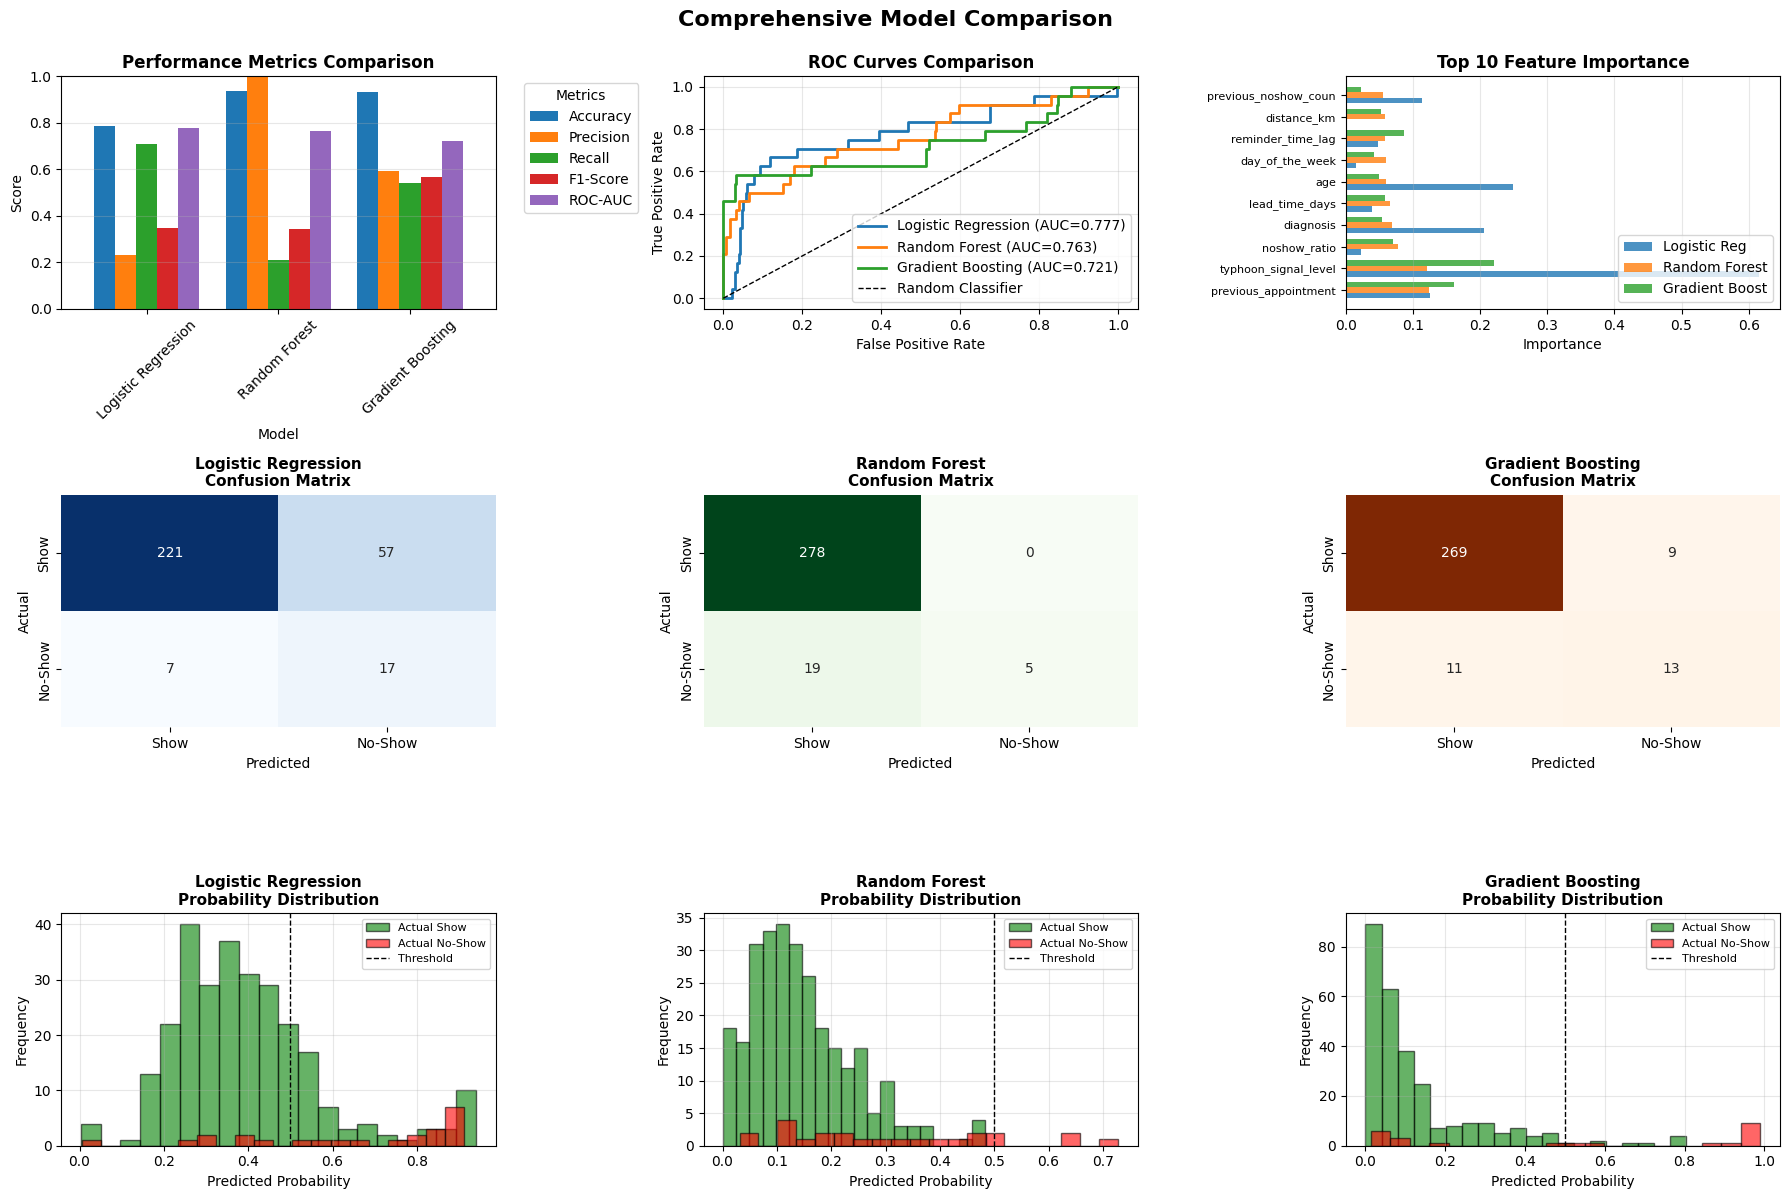

In [ ]:
fig = plt.figure(figsize=(18, 12))

# Performance Metrics Comparison (Bar Chart)
ax1 = plt.subplot(3, 3, 1)
metrics_to_plot = comparison_df.set_index('Metric')
metrics_to_plot.T.plot(kind='bar', ax=ax1, rot=45, width=0.8)
ax1.set_title('Performance Metrics Comparison', fontsize=12, fontweight='bold')
ax1.set_ylabel('Score')
ax1.set_xlabel('Model')
ax1.legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, 1)

# ROC Curves Comparison
ax2 = plt.subplot(3, 3, 2)

# Calculate ROC curves
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr.predict_proba(X_test_scaled)[:, 1])
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf.predict_proba(X_test)[:, 1]) # Use X_test here
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb.predict_proba(X_test)[:, 1]) # Use X_test here

auc_lr = roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1])
auc_rf = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]) # Use X_test here
auc_gb = roc_auc_score(y_test, gb.predict_proba(X_test)[:, 1]) # Use X_test here

ax2.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={auc_lr:.3f})', linewidth=2)
ax2.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf:.3f})', linewidth=2)
ax2.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC={auc_gb:.3f})', linewidth=2)
ax2.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curves Comparison', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right')
ax2.grid(alpha=0.3)

# Feature Importance Comparison - Top 10
ax3 = plt.subplot(3, 3, 3)

top_10_features = rf_feature_importance.head(10)['feature'].values

lr_imp = pd.DataFrame({'feature': feature_cols, 'importance': np.abs(lr.coef_[0])})
lr_imp = lr_imp[lr_imp['feature'].isin(top_10_features)].set_index('feature').reindex(top_10_features)

rf_imp = rf_feature_importance[rf_feature_importance['feature'].isin(top_10_features)].set_index('feature').reindex(top_10_features)
gb_imp = gb_feature_importance[gb_feature_importance['feature'].isin(top_10_features)].set_index('feature').reindex(top_10_features)

x_pos = np.arange(len(top_10_features))
width = 0.25

ax3.barh(x_pos - width, lr_imp['importance'].values, width, label='Logistic Reg', alpha=0.8)
ax3.barh(x_pos, rf_imp['importance'].values, width, label='Random Forest', alpha=0.8)
ax3.barh(x_pos + width, gb_imp['importance'].values, width, label='Gradient Boost', alpha=0.8)

ax3.set_yticks(x_pos)
ax3.set_yticklabels([f.replace('_encoded', '').replace('log_', '')[:20] for f in top_10_features], fontsize=8)
ax3.set_xlabel('Importance')
ax3.set_title('Top 10 Feature Importance', fontsize=12, fontweight='bold')
ax3.legend(loc='lower right')
ax3.grid(axis='x', alpha=0.3)

# Confusion Matrix - Logistic Regression
ax4 = plt.subplot(3, 3, 4)
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=ax4, cbar=False,
            xticklabels=['Show', 'No-Show'], yticklabels=['Show', 'No-Show'])
ax4.set_title('Logistic Regression\nConfusion Matrix', fontsize=11, fontweight='bold')
ax4.set_ylabel('Actual')
ax4.set_xlabel('Predicted')

# Confusion Matrix - Random Forest
ax5 = plt.subplot(3, 3, 5)
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=ax5, cbar=False,
            xticklabels=['Show', 'No-Show'], yticklabels=['Show', 'No-Show'])
ax5.set_title('Random Forest\nConfusion Matrix', fontsize=11, fontweight='bold')
ax5.set_ylabel('Actual')
ax5.set_xlabel('Predicted')

# Confusion Matrix - Gradient Boosting
ax6 = plt.subplot(3, 3, 6)
cm_gb = confusion_matrix(y_test, y_pred_gb)
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Oranges', ax=ax6, cbar=False,
            xticklabels=['Show', 'No-Show'], yticklabels=['Show', 'No-Show'])
ax6.set_title('Gradient Boosting\nConfusion Matrix', fontsize=11, fontweight='bold')
ax6.set_ylabel('Actual')
ax6.set_xlabel('Predicted')

# Probability Distribution - Logistic Regression
ax7 = plt.subplot(3, 3, 7)
pred_proba_lr_show = lr.predict_proba(X_test_scaled[y_test == 0])[:, 1]
pred_proba_lr_noshow = lr.predict_proba(X_test_scaled[y_test == 1])[:, 1]
ax7.hist(pred_proba_lr_show, bins=20, alpha=0.6, label='Actual Show', color='green', edgecolor='black')
ax7.hist(pred_proba_lr_noshow, bins=20, alpha=0.6, label='Actual No-Show', color='red', edgecolor='black')
ax7.axvline(0.5, color='black', linestyle='--', linewidth=1, label='Threshold')
ax7.set_xlabel('Predicted Probability')
ax7.set_ylabel('Frequency')
ax7.set_title('Logistic Regression\nProbability Distribution', fontsize=11, fontweight='bold')
ax7.legend(fontsize=8)
ax7.grid(alpha=0.3)

# Probability Distribution - Random Forest
ax8 = plt.subplot(3, 3, 8)
pred_proba_rf_show = rf.predict_proba(X_test[y_test == 0])[:, 1] # Use X_test here
pred_proba_rf_noshow = rf.predict_proba(X_test[y_test == 1])[:, 1] # Use X_test here
ax8.hist(pred_proba_rf_show, bins=20, alpha=0.6, label='Actual Show', color='green', edgecolor='black')
ax8.hist(pred_proba_rf_noshow, bins=20, alpha=0.6, label='Actual No-Show', color='red', edgecolor='black')
ax8.axvline(0.5, color='black', linestyle='--', linewidth=1, label='Threshold')
ax8.set_xlabel('Predicted Probability')
ax8.set_ylabel('Frequency')
ax8.set_title('Random Forest\nProbability Distribution', fontsize=11, fontweight='bold')
ax8.legend(fontsize=8)
ax8.grid(alpha=0.3)

# Probability Distribution - Gradient Boosting
ax9 = plt.subplot(3, 3, 9)
pred_proba_gb_show = gb.predict_proba(X_test[y_test == 0])[:, 1] # Use X_test here
pred_proba_gb_noshow = gb.predict_proba(X_test[y_test == 1])[:, 1] # Use X_test here
ax9.hist(pred_proba_gb_show, bins=20, alpha=0.6, label='Actual Show', color='green', edgecolor='black')
ax9.hist(pred_proba_gb_noshow, bins=20, alpha=0.6, label='Actual No-Show', color='red', edgecolor='black')
ax9.axvline(0.5, color='black', linestyle='--', linewidth=1, label='Threshold')
ax9.set_xlabel('Predicted Probability')
ax9.set_ylabel('Frequency')
ax9.set_title('Gradient Boosting\nProbability Distribution', fontsize=11, fontweight='bold')
ax9.legend(fontsize=8)
ax9.grid(alpha=0.3)

plt.suptitle('Comprehensive Model Comparison', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## Test Cases

In [ ]:
def predict_new_patient(
    lead_time_days,
    distance_km,
    age,
    typhoon_signal,
    is_weekend,
    previous_noshows,
    total_previous_appts,
    down_payment,
    last_appt_was_noshow,
    day_of_the_week,
    service_type,
    payment_status,
    payment_method,
    diagnosis,
    gender,
    time_of_day,
    has_down_payment,
    is_holiday,
    actual_outcome=None,
    model_to_use='Logistic Regression' # Added argument to select model
):
    # Numerical features with log transforms
    input_data = {
        'log_duration_minutes': np.log1p(60),  # Standard 60-min session
        'down_payment_amount': down_payment,
        'log_lead_time_days': np.log1p(lead_time_days),
        'log_distance_km': np.log1p(distance_km),
        'log_previous_appointment_count': np.log1p(total_previous_appts),
        'last_appt_noshow': last_appt_was_noshow,
        'lead_time_is_missing': 1 if lead_time_days == 0 else 0,
        'is_weekend': is_weekend,
        'reminder_time_lag': 2,  # Default assumption (2 days before)
        'age': age,
        'typhoon_signal_level': typhoon_signal,
        'previous_noshow_count': previous_noshows,
        'noshow_ratio': previous_noshows / total_previous_appts if total_previous_appts > 0 else 0,
    }

    # Encode categorical features
    categorical_mapping = {
        'day_of_the_week': day_of_the_week,
        'service_type': service_type,
        'payment_status': payment_status,
        'payment_method': payment_method,
        'diagnosis': diagnosis,
        'gender': gender,
        'time_of_day': time_of_day,
        'has_down_payment': has_down_payment,
        'is_holiday': is_holiday
    }

    # Label Encoding
    for col, value in categorical_mapping.items():
        if col in le_dict:
            try:
                if str(value) in le_dict[col].classes_:
                    input_data[f'{col}_encoded'] = le_dict[col].transform([str(value)])[0]
                else:

                    input_data[f'{col}_encoded'] = 0
                    print(f"Warning: '{value}' not seen in training for {col}, using default")
            except Exception as e:
                input_data[f'{col}_encoded'] = 0
                print(f"Error encoding {col}: {e}")

    # DataFrame with exact feature order from training
    df_single = pd.DataFrame([input_data])
    df_single = df_single.reindex(columns=feature_cols, fill_value=0)

    # Scale data for Logistic Regression, use unscaled for others
    if model_to_use == 'Logistic Regression':
        df_single_processed = scaler.transform(df_single)
        model = lr
    elif model_to_use == 'Random Forest':
        df_single_processed = df_single # RF does not require scaling
        model = rf
    elif model_to_use == 'Gradient Boosting':
        df_single_processed = df_single # GB does not require scaling
        model = gb
    else:
        raise ValueError("Invalid model_to_use specified. Choose 'Logistic Regression', 'Random Forest', or 'Gradient Boosting'.")

    pred_prob = model.predict_proba(df_single_processed)[0, 1]
    pred_class = model.predict(df_single_processed)[0]

    print("="*70)
    print(f"PATIENT NO-SHOW RISK ASSESSMENT ({model_to_use})")
    print("="*70)
    print(f"Profile:      {age} years old, {gender}, {distance_km} km from clinic")
    print(f"Diagnosis:    {diagnosis}")
    print(f"Service:      {service_type} on {day_of_the_week} {time_of_day}")
    print(f"Financial:    ₱{down_payment} down payment ({payment_status}, {payment_method})的声音)")
    print(f"History:      {previous_noshows} no-shows out of {total_previous_appts} appointments")
    if total_previous_appts > 0:
        print(f"              ({previous_noshows/total_previous_appts*100:.1f}% no-show rate)")
    print(f"Conditions:   Typhoon Signal {typhoon_signal}, Weekend: {bool(is_weekend)}, Holiday: {is_holiday}")
    print(f"Booking:      {lead_time_days} days lead time")
    print("-"*70)

    # Risk assessment
    risk_level = 'HIGH' if pred_prob > 0.5 else 'MODERATE' if pred_prob > 0.3 else 'LOW'
    risk_color = '🔴' if pred_prob > 0.5 else '🟡' if pred_prob > 0.3 else '🟢'

    print(f"PREDICTED NO-SHOW PROBABILITY: {pred_prob:.1%} {risk_color}")
    print(f"RISK CATEGORY: {risk_level}")

    if actual_outcome is not None:
        error = abs(actual_outcome - pred_prob)
        status = "No-Show" if actual_outcome == 1 else "Showed Up"
        correct = "✓" if (pred_prob > 0.5 and actual_outcome == 1) or (pred_prob <= 0.5 and actual_outcome == 0) else "✗"
        print("-"*70)
        print(f"ACTUAL OUTCOME:    {status} {correct}")
        print(f"PREDICTION ERROR:  {error:.1%}")

    print("="*70)

    return pred_prob

In [ ]:
print("\n--- CASE 1: The 'Perfect' Patient (Logistic Regression) ---")
# Lives nearby (2km), Paid 500, No history of skipping
predict_new_patient(lead_time_days=3, distance_km=2, age=4, typhoon_signal=0,
                    is_weekend=1, previous_noshows=0, total_previous_appts=10,
                    down_payment=500, last_appt_was_noshow=0,
                    day_of_the_week='Sun', service_type='OT', payment_status='Updated',
                    payment_method='Gcash', diagnosis='ASD', gender='M',
                    time_of_day='Morning', has_down_payment='Yes', is_holiday='No',
                    actual_outcome=0, model_to_use='Logistic Regression')

print("\n\n--- CASE 2: The 'High Risk' Scenario (Logistic Regression) ---")
# Lives far (25km), Typhoon Signal 2, Has skipped before
predict_new_patient(lead_time_days=30, distance_km=25, age=8, typhoon_signal=2,
                    is_weekend=0, previous_noshows=3, total_previous_appts=5,
                    down_payment=0, last_appt_was_noshow=1,
                    day_of_the_week='Wed', service_type='ST', payment_status='Arrears',
                    payment_method='None', diagnosis='GDD', gender='F',
                    time_of_day='Afternoon', has_down_payment='No', is_holiday='No',
                    actual_outcome=1, model_to_use='Logistic Regression')

print("\n\n--- CASE 3: New Patient, Holiday, Weekend, No Down Payment (Moderately High Risk) (Logistic Regression) ---")
predict_new_patient(lead_time_days=1, distance_km=10, age=4, typhoon_signal=0,
                    is_weekend=1, previous_noshows=0, total_previous_appts=0, # New patient, no previous appts
                    down_payment=0, last_appt_was_noshow=0,
                    day_of_the_week='Sat', service_type='ST', payment_status='Arrears',
                    payment_method='None', diagnosis='ADHD', gender='M',
                    time_of_day='Morning', has_down_payment='No', is_holiday='Yes',
                    actual_outcome=1, model_to_use='Logistic Regression')

print("\n\n--- CASE 4: Loyal Patient, Far Distance, Weekday (Logistic Regression) ---")
predict_new_patient(lead_time_days=7, distance_km=40, age=6, typhoon_signal=0,
                    is_weekend=0, previous_noshows=1, total_previous_appts=20,
                    down_payment=1000, last_appt_was_noshow=0,
                    day_of_the_week='Mon', service_type='OT', payment_status='Updated',
                    payment_method='BDO', diagnosis='SLD', gender='F',
                    time_of_day='Lunch', has_down_payment='Yes', is_holiday='No',
                    actual_outcome=0, model_to_use='Logistic Regression')

print("\n\n--- CASE 5: The 'High Risk' Scenario (Random Forest) ---")
predict_new_patient(lead_time_days=30, distance_km=25, age=8, typhoon_signal=2,
                    is_weekend=0, previous_noshows=3, total_previous_appts=5,
                    down_payment=0, last_appt_was_noshow=1,
                    day_of_the_week='Wed', service_type='ST', payment_status='Arrears',
                    payment_method='None', diagnosis='GDD', gender='F',
                    time_of_day='Afternoon', has_down_payment='No', is_holiday='No',
                    actual_outcome=1, model_to_use='Random Forest')

print("\n\n--- CASE 6: The 'High Risk' Scenario (Gradient Boosting) ---")
predict_new_patient(lead_time_days=30, distance_km=25, age=8, typhoon_signal=2,
                    is_weekend=0, previous_noshows=3, total_previous_appts=5,
                    down_payment=0, last_appt_was_noshow=1,
                    day_of_the_week='Wed', service_type='ST', payment_status='Arrears',
                    payment_method='None', diagnosis='GDD', gender='F',
                    time_of_day='Afternoon', has_down_payment='No', is_holiday='No',
                    actual_outcome=1, model_to_use='Gradient Boosting')



--- CASE 1: The 'Perfect' Patient (Logistic Regression) ---
PATIENT NO-SHOW RISK ASSESSMENT (Logistic Regression)
Profile:      4 years old, M, 2 km from clinic
Diagnosis:    ASD
Service:      OT on Sun Morning
Financial:    ₱500 down payment (Updated, Gcash)的声音)
History:      0 no-shows out of 10 appointments
              (0.0% no-show rate)
Conditions:   Typhoon Signal 0, Weekend: True, Holiday: No
Booking:      3 days lead time
----------------------------------------------------------------------
PREDICTED NO-SHOW PROBABILITY: 19.6% 🟢
RISK CATEGORY: LOW
----------------------------------------------------------------------
ACTUAL OUTCOME:    Showed Up ✓
PREDICTION ERROR:  19.6%


--- CASE 2: The 'High Risk' Scenario (Logistic Regression) ---
PATIENT NO-SHOW RISK ASSESSMENT (Logistic Regression)
Profile:      8 years old, F, 25 km from clinic
Diagnosis:    GDD
Service:      ST on Wed Afternoon
Financial:    ₱0 down payment (Arrears, None)的声音)
History:      3 no-shows out of 5 appo

np.float64(0.9751203703427579)

**Key Determinants of No-Shows (Hypothesis Testing):**

1. Financial Commitment (H1): There was no significant difference in no-show rates based on whether a down payment was made or not. The current deposit system does not strongly incentivize attendance.
2. Temporal Patterns (H2): No-show rates differ significantly by day of the week and appointment time. Weekday appointments, especially on Wednesdays, and early morning slots have higher no-show risks. Weekend appointments have lower no-show rates.
3. Environmental Factors (H3): Both holidays and typhoon signal levels significantly impact no-show rates. Higher typhoon signal levels strongly correlate with increased no-shows.
4. Demographics and Clinical Profiles (H4): While some diagnoses (e.g., GDD, ODD) and older age groups (7-9 years) showed slightly higher descriptive no-show rates, these differences were not statistically significant after formal hypothesis testing for the specified categories. Similarly, distance categories did not show a statistically significant difference.
5. Historical Behavior (H5): A patient's previous no-show count and ratio are significant predictors of future no-shows. Patients with a history of missing appointments are more likely to miss future ones.


**Feature Importance:**

* Typhoon Signal Level consistently appeared as a top predictor across all models, highlighting its strong influence on attendance.
* Log-transformed previous appointment count and noshow_ratio were important, reinforcing the significance of historical behavior.
* Lead time indicators (log_lead_time_days, lead_time_is_missing) and patient age also showed considerable importance.

The analysis reveals that external factors (typhoon risk, temporal patterns) and a patient's historical attendance behavior are the most powerful predictors of no-shows.